In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_E408.csv")

df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14100 entries, 0 to 14099
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   datetime        14100 non-null  object 
 1   PM10            13921 non-null  float64
 2   PM2.5           13921 non-null  float64
 3   temperature     13885 non-null  float64
 4   rain            13885 non-null  float64
 5   pressure        13870 non-null  float64
 6   precipitation   13885 non-null  float64
 7   wind_speed      13885 non-null  float64
 8   clouds          13885 non-null  object 
 9   wind_direction  7168 non-null   object 
dtypes: float64(7), object(3)
memory usage: 1.1+ MB


(              datetime  PM10  PM2.5  temperature  rain  pressure  \
 0  2024-05-02 20:00:00   6.0    3.0         14.0   1.5    1007.0   
 1  2024-05-02 21:00:00   4.0    2.0         12.0   0.5    1007.0   
 2  2024-05-02 22:00:00   6.0    2.0         12.0   0.8    1007.0   
 3  2024-05-02 23:00:00   6.0    3.0         11.0   0.0    1007.0   
 4  2024-05-03 00:00:00   6.0    3.0         10.0   0.0    1007.0   
 
    precipitation  wind_speed            clouds wind_direction  
 0           76.0         6.0           oblačno            NaN  
 1           81.0         1.0           oblačno            NaN  
 2           88.0         2.0           oblačno            NaN  
 3           76.0         1.0  pretežno oblačno            NaN  
 4           85.0         1.0  pretežno oblačno            NaN  ,
 None)

In [63]:
# pretvorba v datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# sortiranje po času
df = df.sort_values("datetime").reset_index(drop=True)

# preverim časovni interval
df["datetime"].diff().value_counts().head()

datetime
0 days 01:00:00    14099
Name: count, dtype: int64

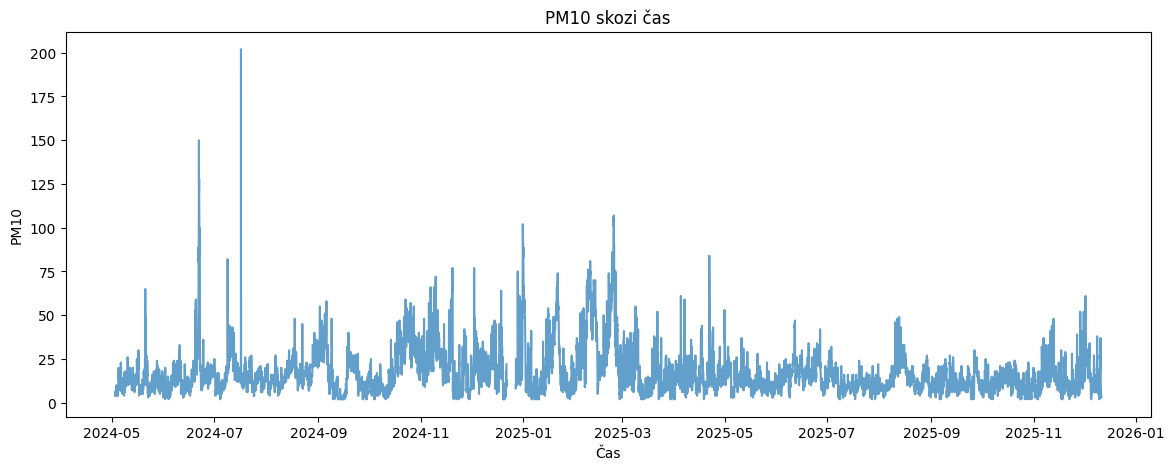

In [3]:
plt.figure(figsize=(14,5))
plt.plot(df["datetime"], df["PM10"], alpha=0.7)
plt.title("PM10 skozi čas")
plt.xlabel("Čas")
plt.ylabel("PM10")
plt.show()

In [4]:
df.isnull().sum()

datetime             0
PM10               179
PM2.5              179
temperature        215
rain               215
pressure           230
precipitation      215
wind_speed         215
clouds             215
wind_direction    6932
dtype: int64

In [64]:
from sklearn.ensemble import RandomForestRegressor

# Kopija podatkov
df_filled = df.copy()

# ČIŠČENJE KATEGORIČNIH STOLPCEV + UNKNOWN
for c in ["clouds", "wind_direction"]:
    df_filled[c] = df_filled[c].astype("string").str.strip()
    df_filled[c] = df_filled[c].fillna("unknown")

# ONE-HOT ENCODING KATEGORIČNIH SPREMENLJIVK
cat_dummies = pd.get_dummies(
    df_filled[["clouds", "wind_direction"]],
    prefix=["clouds", "wind_direction"],
    drop_first=False
)

# združim numerične + one-hot, string stolpce odstranim
df_model = pd.concat(
    [df_filled.drop(columns=["clouds", "wind_direction"]), cat_dummies],
    axis=1
)

# funkcija za rf imputacijo oz zapolnitev posameznega stolpca
def rf_impute_column(df_in, target_col, feature_cols,
                     n_estimators=300, random_state=42):
    df_out = df_in.copy()

    # če ni manjkajočih -> nič ne delam
    if df_out[target_col].isna().sum() == 0:
        return df_out

    train_part = df_out[df_out[target_col].notna()]
    pred_part  = df_out[df_out[target_col].isna()]

    X_train = train_part[feature_cols]
    y_train = train_part[target_col]
    X_pred  = pred_part[feature_cols]

    # ker RF ne podpira NaN → očistim train
    valid_mask = X_train.notna().all(axis=1)
    X_train = X_train[valid_mask]
    y_train = y_train[valid_mask]

    # v pred delu zapolnim NaN z medianami iz train
    medians = X_train.median()
    X_pred = X_pred.fillna(medians)

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    df_out.loc[df_out[target_col].isna(), target_col] = rf.predict(X_pred)
    return df_out


# zaporedna imputacija (brez data leakage)
weather_cols   = ["temperature", "rain", "pressure", "precipitation", "wind_speed"]
pollution_cols = ["PM2.5", "PM10"]  # PM10 zadnji (ciljna spremenljivka)

# vsi feature stolpci razen datetime
feature_base = [c for c in df_model.columns if c != "datetime"]

# najprej vreme
for col in weather_cols:
    feature_cols = [c for c in feature_base if c != col]
    df_model = rf_impute_column(df_model, col, feature_cols)

# potem PM2.5
col = "PM2.5"
feature_cols = [c for c in feature_base if c != col]
df_model = rf_impute_column(df_model, col, feature_cols)

# nazadnje PM10
col = "PM10"
feature_cols = [c for c in feature_base if c != col]
df_model = rf_impute_column(df_model, col, feature_cols)


# končni podatki po zapolnitvi
df_filled = df_model.copy()

print("Manjkajoče vrednosti po RF imputaciji:")
print(df_filled.isnull().sum())

df_filled.head()

Manjkajoče vrednosti po RF imputaciji:
datetime                   0
PM10                       0
PM2.5                      0
temperature                0
rain                       0
pressure                   0
precipitation              0
wind_speed                 0
clouds_delno oblačno       0
clouds_jasno               0
clouds_oblačno             0
clouds_pretežno oblačno    0
clouds_unknown             0
wind_direction_J           0
wind_direction_JV          0
wind_direction_JZ          0
wind_direction_S           0
wind_direction_SV          0
wind_direction_SZ          0
wind_direction_V           0
wind_direction_Z           0
wind_direction_unknown     0
dtype: int64


,datetime,PM10,PM2.5,temperature,rain,pressure,precipitation,wind_speed,clouds_delno oblačno,clouds_jasno,...,clouds_unknown,wind_direction_J,wind_direction_JV,wind_direction_JZ,wind_direction_S,wind_direction_SV,wind_direction_SZ,wind_direction_V,wind_direction_Z,wind_direction_unknown
0,2024-05-02 20:00:00,6.0,3.0,14.0,1.5,1007.0,76.0,6.0,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2024-05-02 21:00:00,4.0,2.0,12.0,0.5,1007.0,81.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2024-05-02 22:00:00,6.0,2.0,12.0,0.8,1007.0,88.0,2.0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2024-05-02 23:00:00,6.0,3.0,11.0,0.0,1007.0,76.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2024-05-03 00:00:00,6.0,3.0,10.0,0.0,1007.0,85.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,True


In [65]:
# ČASOVNE ZNAČILNICE
df_feat = df_filled.copy()

df_feat["hour"] = df_feat["datetime"].dt.hour
df_feat["dayofweek"] = df_feat["datetime"].dt.dayofweek
df_feat["month"] = df_feat["datetime"].dt.month

# ciklična predstavitev ure
df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)

# ciklična predstavitev dneva v tednu
df_feat["dow_sin"] = np.sin(2 * np.pi * df_feat["dayofweek"] / 7)
df_feat["dow_cos"] = np.cos(2 * np.pi * df_feat["dayofweek"] / 7)

# datetime ne potrebujemo več kot feature
df_feat = df_feat.drop(columns=["datetime"])

df_feat.head()

,PM10,PM2.5,temperature,rain,pressure,precipitation,wind_speed,clouds_delno oblačno,clouds_jasno,clouds_oblačno,...,wind_direction_V,wind_direction_Z,wind_direction_unknown,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,6.0,3.0,14.0,1.5,1007.0,76.0,6.0,False,False,True,...,False,False,True,20,3,5,-0.866025,0.500000,0.433884,-0.900969
1,4.0,2.0,12.0,0.5,1007.0,81.0,1.0,False,False,True,...,False,False,True,21,3,5,-0.707107,0.707107,0.433884,-0.900969
2,6.0,2.0,12.0,0.8,1007.0,88.0,2.0,False,False,True,...,False,False,True,22,3,5,-0.500000,0.866025,0.433884,-0.900969
3,6.0,3.0,11.0,0.0,1007.0,76.0,1.0,False,False,False,...,False,False,True,23,3,5,-0.258819,0.965926,0.433884,-0.900969
4,6.0,3.0,10.0,0.0,1007.0,85.0,1.0,False,False,False,...,False,False,True,0,4,5,0.000000,1.000000,-0.433884,-0.900969


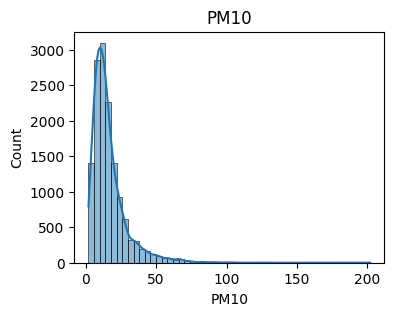

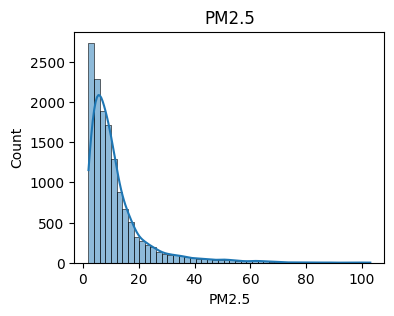

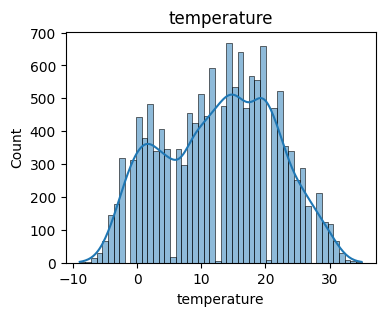

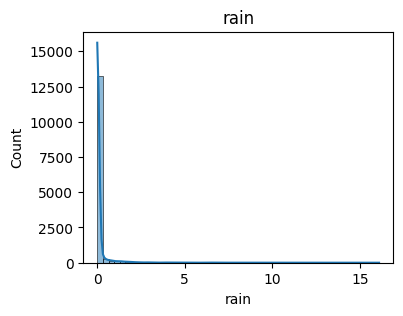

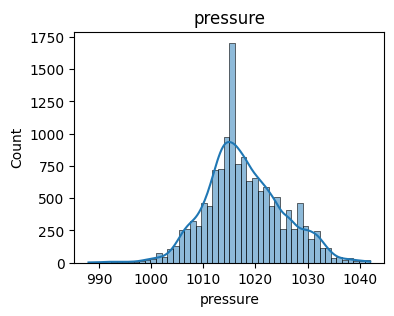

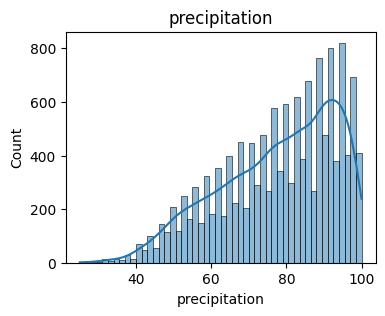

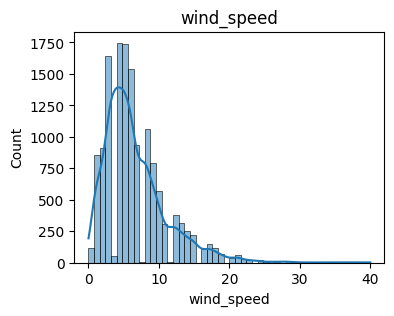

In [7]:
import seaborn as sns

num_cols_to_check = [
    "PM10", "PM2.5", "temperature", "rain",
    "pressure", "precipitation", "wind_speed"
]

for col in num_cols_to_check:
    plt.figure(figsize=(4,3))
    sns.histplot(df_feat[col], bins=50, kde=True)
    plt.title(col)
    plt.show()

In [66]:
#Transformacije
df_fe = df_filled.copy()

df_fe["PM10_log"] = np.log1p(df_fe["PM10"])
df_fe["PM2_5_log"] = np.log1p(df_fe["PM2.5"])
df_fe["rain_log"] = np.log1p(df_fe["rain"])
df_fe["wind_speed_log"] = np.log1p(df_fe["wind_speed"])

In [67]:
df_fe[[
    "PM10", "PM10_log",
    "PM2.5", "PM2_5_log",
    "rain", "rain_log",
    "wind_speed", "wind_speed_log"
]].head()

,PM10,PM10_log,PM2.5,PM2_5_log,rain,rain_log,wind_speed,wind_speed_log
0,6.0,1.945910,3.0,1.386294,1.5,0.916291,6.0,1.945910
1,4.0,1.609438,2.0,1.098612,0.5,0.405465,1.0,0.693147
2,6.0,1.945910,2.0,1.098612,0.8,0.587787,2.0,1.098612
3,6.0,1.945910,3.0,1.386294,0.0,0.000000,1.0,0.693147
4,6.0,1.945910,3.0,1.386294,0.0,0.000000,1.0,0.693147


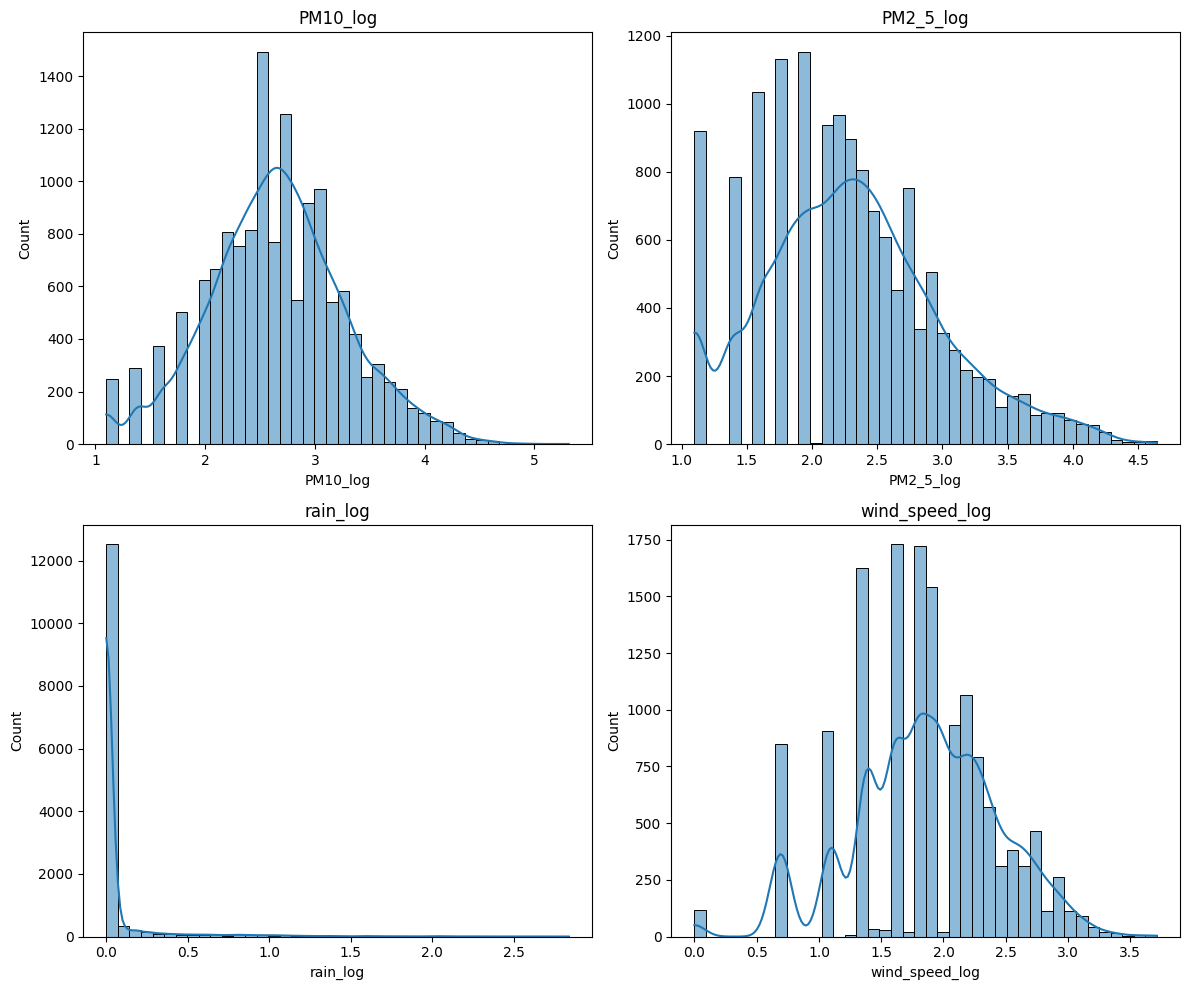

In [10]:
log_cols = [
    "PM10_log",
    "PM2_5_log",
    "rain_log",
    "wind_speed_log"
]

plt.figure(figsize=(12, 10))

for i, col in enumerate(log_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_fe[col], kde=True, bins=40)
    plt.title(col)

plt.tight_layout()
plt.show()

In [68]:
# Nove značilnice

# Drseče povprečje (24 ur)
df_fe["PM10_roll_24"] = df_fe["PM10_log"].rolling(24).mean()

# Kratkoročna sprememba
df_fe["PM10_diff_1"] = df_fe["PM10_log"].diff(1)

# Srednjeročna sprememba
df_fe["PM10_diff_6"] = df_fe["PM10_log"].diff(6)

# Interakcija temperature in vetra
df_fe["temp_wind_interaction"] = df_fe["temperature"] * df_fe["wind_speed_log"]

# Binarna značilnica: ali dežuje
df_fe["is_rain"] = (df_fe["rain"] > 0).astype(int)

df_fe.head()

,datetime,PM10,PM2.5,temperature,rain,pressure,precipitation,wind_speed,clouds_delno oblačno,clouds_jasno,...,wind_direction_unknown,PM10_log,PM2_5_log,rain_log,wind_speed_log,PM10_roll_24,PM10_diff_1,PM10_diff_6,temp_wind_interaction,is_rain
0,2024-05-02 20:00:00,6.0,3.0,14.0,1.5,1007.0,76.0,6.0,False,False,...,True,1.945910,1.386294,0.916291,1.945910,NaN,NaN,NaN,27.242742,1
1,2024-05-02 21:00:00,4.0,2.0,12.0,0.5,1007.0,81.0,1.0,False,False,...,True,1.609438,1.098612,0.405465,0.693147,NaN,-0.336472,NaN,8.317766,1
2,2024-05-02 22:00:00,6.0,2.0,12.0,0.8,1007.0,88.0,2.0,False,False,...,True,1.945910,1.098612,0.587787,1.098612,NaN,0.336472,NaN,13.183347,1
3,2024-05-02 23:00:00,6.0,3.0,11.0,0.0,1007.0,76.0,1.0,False,False,...,True,1.945910,1.386294,0.000000,0.693147,NaN,0.000000,NaN,7.624619,0
4,2024-05-03 00:00:00,6.0,3.0,10.0,0.0,1007.0,85.0,1.0,False,False,...,True,1.945910,1.386294,0.000000,0.693147,NaN,0.000000,NaN,6.931472,0


In [69]:
df_fe = df_fe.dropna().reset_index(drop=True)
df_fe.isnull().sum()

datetime                   0
PM10                       0
PM2.5                      0
temperature                0
rain                       0
pressure                   0
precipitation              0
wind_speed                 0
clouds_delno oblačno       0
clouds_jasno               0
clouds_oblačno             0
clouds_pretežno oblačno    0
clouds_unknown             0
wind_direction_J           0
wind_direction_JV          0
wind_direction_JZ          0
wind_direction_S           0
wind_direction_SV          0
wind_direction_SZ          0
wind_direction_V           0
wind_direction_Z           0
wind_direction_unknown     0
PM10_log                   0
PM2_5_log                  0
rain_log                   0
wind_speed_log             0
PM10_roll_24               0
PM10_diff_1                0
PM10_diff_6                0
temp_wind_interaction      0
is_rain                    0
dtype: int64

In [70]:
# IZBIRA ZNAČILNIC (Mutual Information)
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np

# Target (napovedujem PM10_log)
target_col = "PM10_log"

# Vrzem ven datetime + original PM10
drop_cols = ["datetime", "PM10"]
X = df_fe.drop(columns=[target_col] + drop_cols, errors="ignore")
y = df_fe[target_col].astype(float)

# mutual_info_regression zahteva numeriko -> bool pretvorim v int
for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(int)

# Izračun MI (Information Gain)
mi = mutual_info_regression(X, y, random_state=42)

mi_df = (
    pd.DataFrame({"feature": X.columns, "mi": mi})
    .sort_values("mi", ascending=False)
    .reset_index(drop=True)
)

print("TOP 20 značilnic po Mutual Information:")
display(mi_df.head(20))

TOP 20 značilnic po Mutual Information:


,feature,mi
0,PM10_diff_1,1.958720
1,PM10_diff_6,1.946276
2,PM2.5,1.350567
3,PM2_5_log,1.340019
4,PM10_roll_24,0.581891
5,temperature,0.153030
6,pressure,0.146492
7,temp_wind_interaction,0.144102
8,wind_speed_log,0.083988
9,wind_speed,0.081171


In [71]:
# Izberem značilnice nad pragom 
MI_THRESHOLD = 0.05
selected_features = mi_df.loc[mi_df["mi"] >= MI_THRESHOLD, "feature"].tolist()

print(f"\nIzbrane značilnice (MI >= {MI_THRESHOLD}): {len(selected_features)}")
print(selected_features)

# Končni X_selected (za skaliranje in okna)
X_selected = X[selected_features].copy()

print("\nShape X_selected:", X_selected.shape, " | y:", y.shape)


Izbrane značilnice (MI >= 0.05): 11
['PM10_diff_1', 'PM10_diff_6', 'PM2.5', 'PM2_5_log', 'PM10_roll_24', 'temperature', 'pressure', 'temp_wind_interaction', 'wind_speed_log', 'wind_speed', 'precipitation']

Shape X_selected: (14077, 11)  | y: (14077,)


In [72]:
# TRAIN / TEST SPLIT (časovna vrsta – brez shuffle)

# prepričam se, da je datetime datetime tip
df_fe["datetime"] = pd.to_datetime(df_fe["datetime"])

# sortiram (za vsak slučaj)
df_fe = df_fe.sort_values("datetime").reset_index(drop=True)

# meja: prvo leto za train
split_date = df_fe["datetime"].min() + pd.DateOffset(years=1)

train_df = df_fe[df_fe["datetime"] < split_date].copy()
test_df  = df_fe[df_fe["datetime"] >= split_date].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Train od:", train_df["datetime"].min(), "do", train_df["datetime"].max())
print("Test  od:", test_df["datetime"].min(), "do", test_df["datetime"].max())

Train: (8760, 31)
Test : (5317, 31)
Train od: 2024-05-03 19:00:00 do 2025-05-03 18:00:00
Test  od: 2025-05-03 19:00:00 do 2025-12-11 07:00:00


In [77]:
from sklearn.preprocessing import StandardScaler

# STANDARDIZACIJA
TARGET_COL = "PM10_log"
selected_features = ['PM10_diff_1', 'PM10_diff_6', 'PM2.5', 'PM2_5_log', 'PM10_roll_24',
                     'temperature', 'pressure', 'temp_wind_interaction', 'wind_speed_log',
                     'wind_speed', 'precipitation']

# X / y
X_train = train_df[selected_features].copy()
y_train = train_df[TARGET_COL].astype(float).values

X_test  = test_df[selected_features].copy()
y_test  = test_df[TARGET_COL].astype(float).values

# fit scaler SAMO na train (brez leakage)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape, " y_train:", y_train.shape)
print("X_test_scaled :", X_test_scaled.shape,  " y_test :", y_test.shape)

X_train_scaled: (8760, 11)  y_train: (8760,)
X_test_scaled : (5317, 11)  y_test : (5317,)


In [17]:
print("Train mean (po skaliranju):", X_train_scaled.mean(axis=0).round(2))
print("Train std  (po skaliranju):", X_train_scaled.std(axis=0).round(2))

Train mean (po skaliranju): [-0. -0. -0.  0.  0.  0.  0.  0. -0. -0. -0.]
Train std  (po skaliranju): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [75]:
# PRIPRAVA ČASOVNIH OKEN (multivariantna časovna vrsta) 

# okno (ur) - max 168 (1 teden)
WINDOW_SIZE = 72  # torej lahko 24, 48, 72, 168

def make_windows(X, y, window_size):
    """
    X: (N, n_features)
    y: (N,)
    vrne:
      X_out: (N-window_size, window_size, n_features)
      y_out: (N-window_size,)
    """
    X_out, y_out = [], []
    for i in range(len(X) - window_size):
        X_out.append(X[i:i+window_size, :])
        y_out.append(y[i+window_size])
    return np.array(X_out), np.array(y_out)

# train okna
X_train_seq, y_train_seq = make_windows(X_train_scaled, y_train, WINDOW_SIZE)

# test okna
X_test_seq, y_test_seq = make_windows(X_test_scaled, y_test, WINDOW_SIZE)

print("WINDOW_SIZE:", WINDOW_SIZE)
print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape,  "y_test_seq :", y_test_seq.shape)

# sanity check: Keras pričakuje (samples, timesteps, features)
n_features = X_train_seq.shape[2]
print("n_features:", n_features)

WINDOW_SIZE: 72
X_train_seq: (8688, 72, 11) y_train_seq: (8688,)
X_test_seq : (5245, 72, 11) y_test_seq : (5245,)
n_features: 11


In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Bidirectional, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score

# VALIDACIJA ZNOTRAJ TRAIN (brez shuffle)
# vzamem zadnjih 15% train oken za validacijo
val_frac = 0.15
val_size = int(len(X_train_seq) * val_frac)

X_tr = X_train_seq[:-val_size]
y_tr = y_train_seq[:-val_size]
X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]

print("Train split:", X_tr.shape, y_tr.shape)
print("Val split  :", X_val.shape, y_val.shape)
print("Test       :", X_test_seq.shape, y_test_seq.shape)

timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]
input_shape = (timesteps, n_features)

Train split: (7385, 72, 11) (7385,)
Val split  : (1303, 72, 11) (1303,)
Test       : (5245, 72, 11) (5245,)


In [21]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

def train_and_plot_basic(model, model_name, X_tr, y_tr, X_val, y_val, epochs=25, batch_size=32):
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,   # časovna vrsta -> brez shuffle
        verbose=1,
        callbacks=[es]
    )

    plt.figure(figsize=(10,4))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Val loss")
    plt.title(f"{model_name} - Learning curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

    return history

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - loss: 0.7498 - val_loss: 0.5017
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1933 - val_loss: 0.2293
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1057 - val_loss: 0.1502
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0870 - val_loss: 0.1338
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0793 - val_loss: 0.1286
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0743 - val_loss: 0.1315
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0708 - val_loss: 0.1363
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0718 - val_loss: 0.1655
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0696 - val_loss: 0.1291
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0647 - val_loss: 0.1356


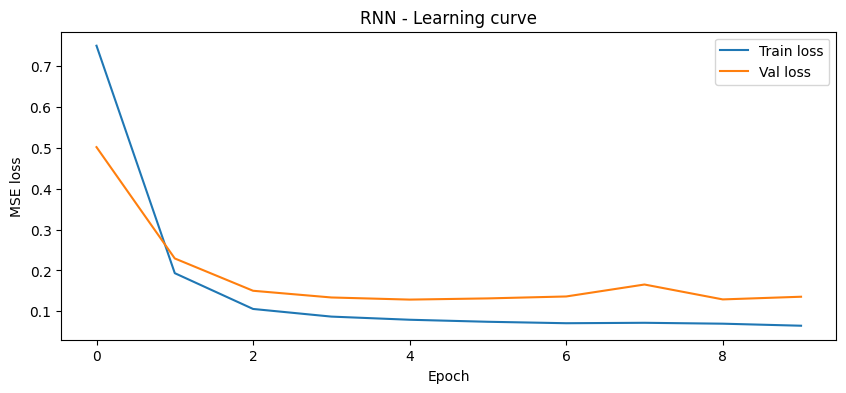

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([
    Input(shape=input_shape),
    SimpleRNN(32, return_sequences=True),
    SimpleRNN(32),
    Dense(16, activation="relu"),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(), loss="mse")

rnn_hist = train_and_plot_basic(rnn_model, "RNN", X_tr, y_tr, X_val, y_val, epochs=25, batch_size=32)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - loss: 1.0934 - val_loss: 0.1853
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - loss: 0.0801 - val_loss: 0.0987
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - loss: 0.0566 - val_loss: 0.0880
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 0.0529 - val_loss: 0.0859
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - loss: 0.0508 - val_loss: 0.0845
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 0.0492 - val_loss: 0.0833
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 0.0479 - val_loss: 0.0821
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - loss: 0.0465 - val_loss: 0.0807
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 0.0454 - val_loss: 0.0792
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 0.0444 - val_loss: 0.0776
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - loss: 0.0436 - val_loss: 0.0754
Epoch 12/25
231/231 ━━━━━━━━━━

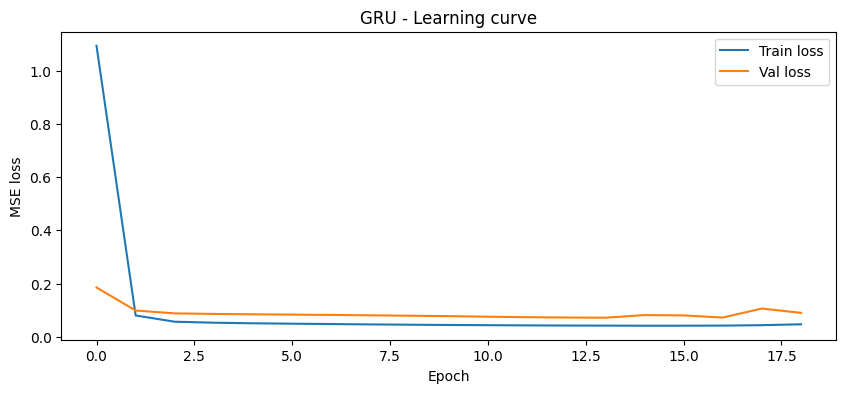

In [23]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Input(shape=input_shape),
    GRU(32, return_sequences=True),
    GRU(32),
    Dense(16, activation="relu"),
    Dense(1)
])

gru_model.compile(optimizer=Adam(), loss="mse")

gru_hist = train_and_plot_basic(gru_model, "GRU", X_tr, y_tr, X_val, y_val, epochs=25, batch_size=32)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 1.2442 - val_loss: 0.2583
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - loss: 0.1022 - val_loss: 0.1113
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - loss: 0.0664 - val_loss: 0.0933
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - loss: 0.0597 - val_loss: 0.0908
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.0577 - val_loss: 0.0913
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.0561 - val_loss: 0.0906
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.0556 - val_loss: 0.0910
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - loss: 0.0536 - val_loss: 0.0892
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - loss: 0.0531 - val_loss: 0.0902
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0520 - val_loss: 0.0890
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 0.0503 - val_loss: 0.0890
Epoch 12/25
231/231 ━━━━━━━━━━

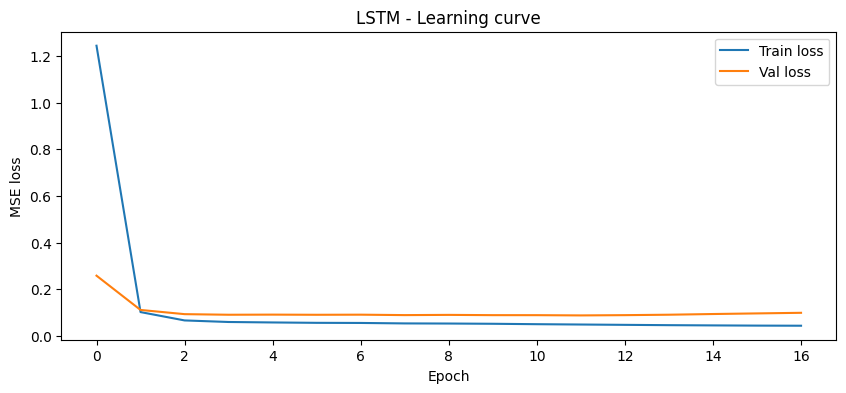

In [24]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Input(shape=input_shape),
    LSTM(32, return_sequences=True),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(), loss="mse")

lstm_hist = train_and_plot_basic(lstm_model, "LSTM", X_tr, y_tr, X_val, y_val, epochs=25, batch_size=32)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - loss: 0.7825 - val_loss: 0.1957
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 0.0857 - val_loss: 0.1040
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - loss: 0.0618 - val_loss: 0.0860
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0543 - val_loss: 0.0854
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.0501 - val_loss: 0.0885
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - loss: 0.0487 - val_loss: 0.0884
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.0472 - val_loss: 0.0877
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - loss: 0.0457 - val_loss: 0.0857
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.0446 - val_loss: 0.0859


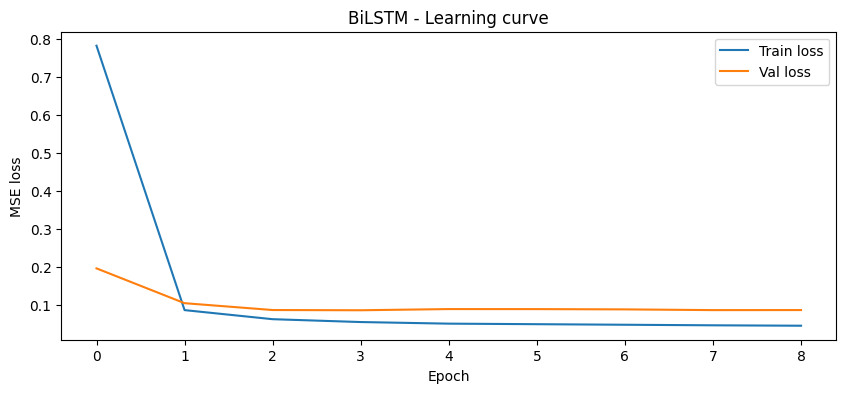

In [25]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([
    Input(shape=input_shape),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(16, activation="relu"),
    Dense(1)
])

bilstm_model.compile(optimizer=Adam(), loss="mse")

bilstm_hist = train_and_plot_basic(bilstm_model, "BiLSTM", X_tr, y_tr, X_val, y_val, epochs=25, batch_size=32)

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score

def regression_metrics_real_pm10(y_true_log, y_pred_log):
    # nazaj na real PM10
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return mae, mape, mse, evs

def evaluate_model_simple(model, name, X_test, y_test_log):
    y_pred_log = model.predict(X_test).reshape(-1)
    mae, mape, mse, evs = regression_metrics_real_pm10(y_test_log, y_pred_log)
    return {"Model": name, "MAE": mae, "MAPE": mape, "MSE": mse, "EVS": evs}

results = []
results.append(evaluate_model_simple(rnn_model, "RNN", X_test_seq, y_test_seq))
results.append(evaluate_model_simple(gru_model, "GRU", X_test_seq, y_test_seq))
results.append(evaluate_model_simple(lstm_model, "LSTM", X_test_seq, y_test_seq))
results.append(evaluate_model_simple(bilstm_model, "BiLSTM", X_test_seq, y_test_seq))

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step


,Model,MAE,MAPE,MSE,EVS
0,GRU,2.248787,21.269427,10.477761,0.787349
1,RNN,2.525113,23.290272,13.074666,0.732979
2,LSTM,2.803022,27.226553,14.659673,0.728408
3,BiLSTM,3.090345,29.430337,16.373385,0.751062


164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step


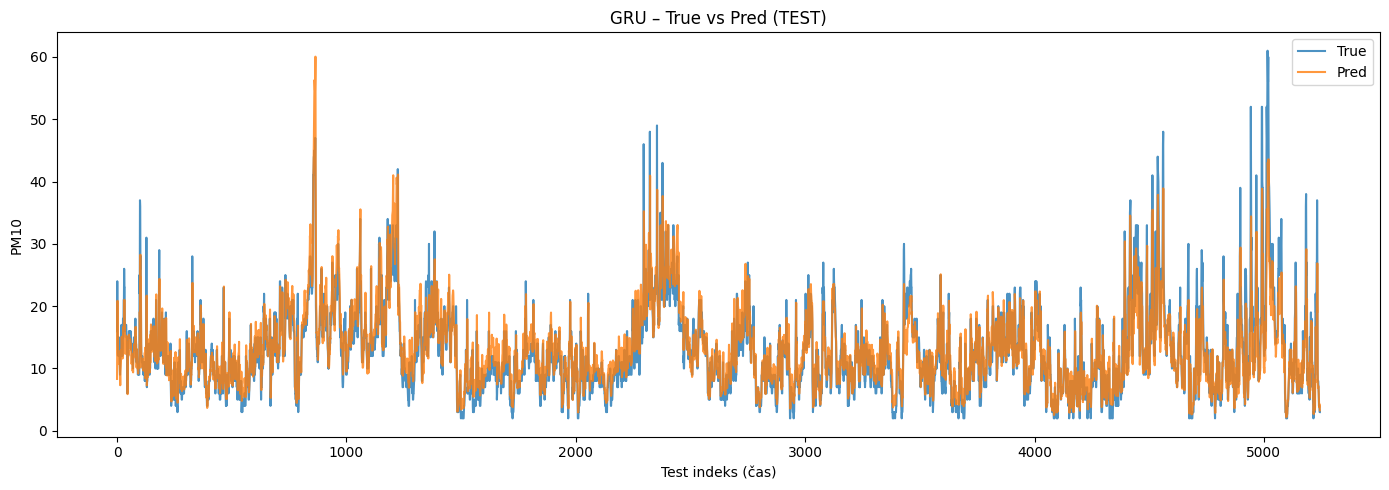

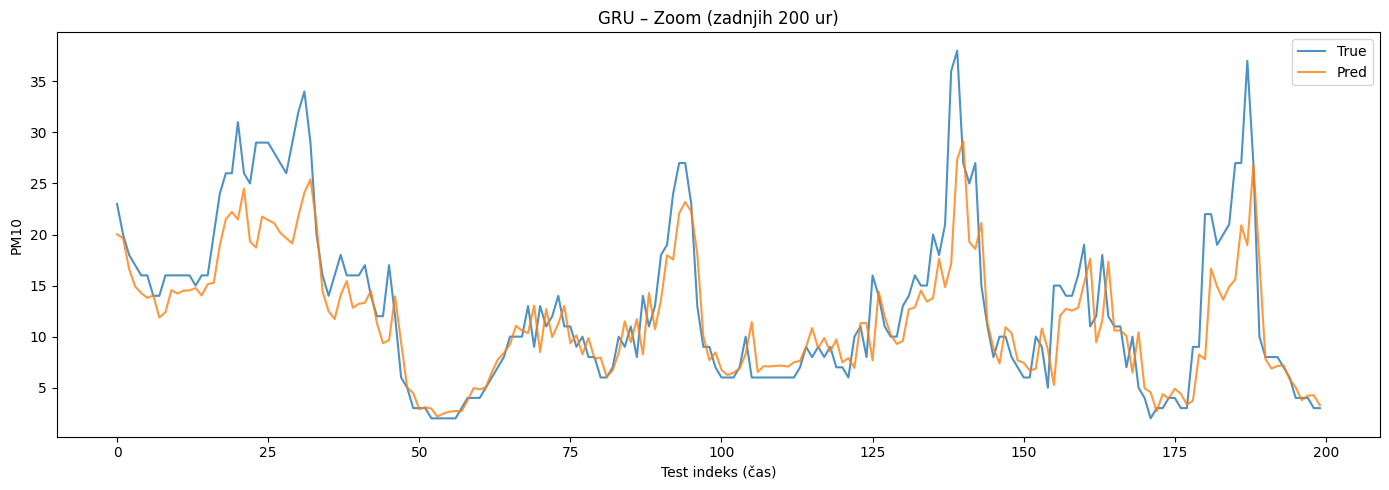

164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


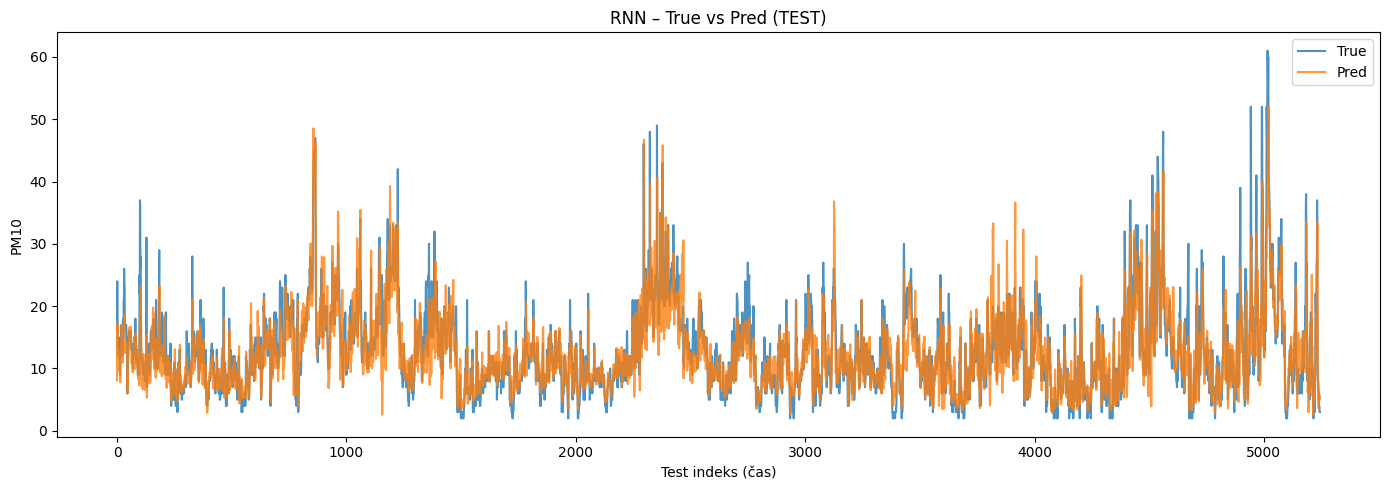

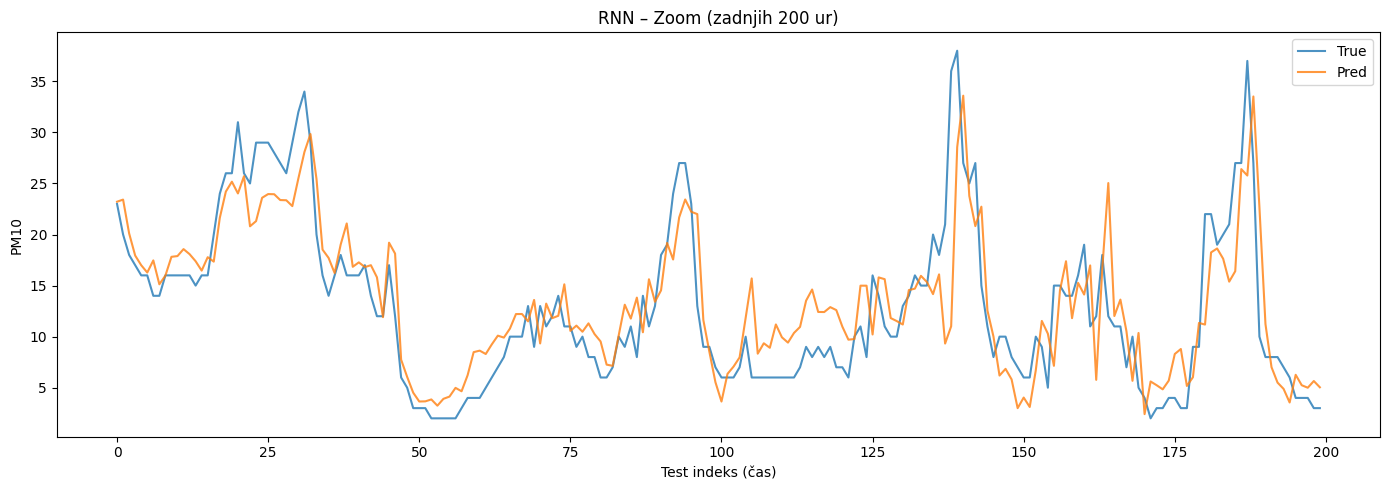

164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step


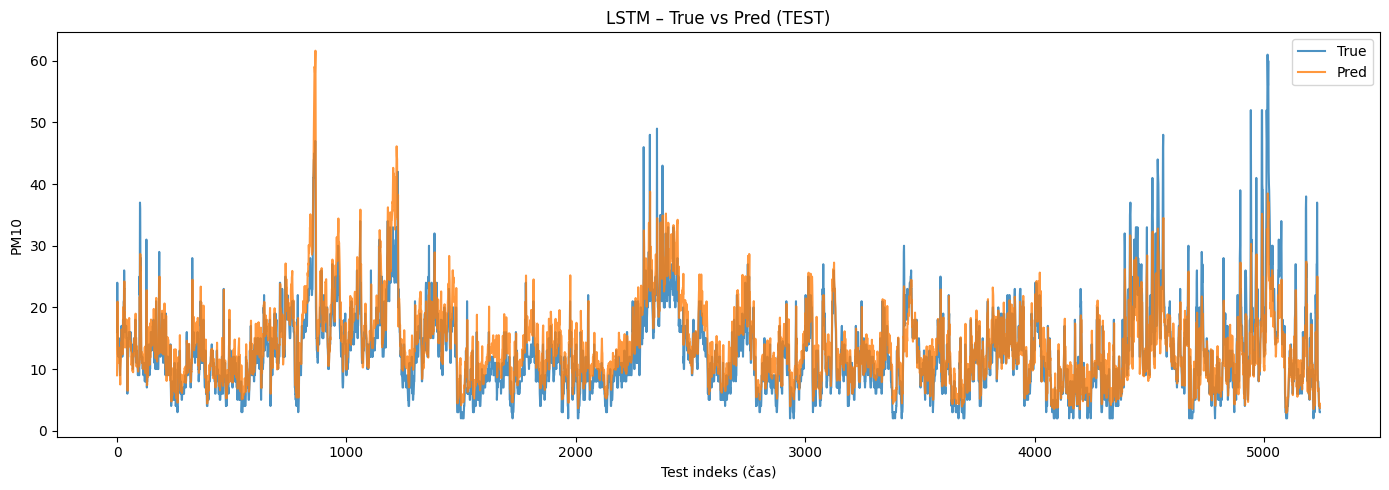

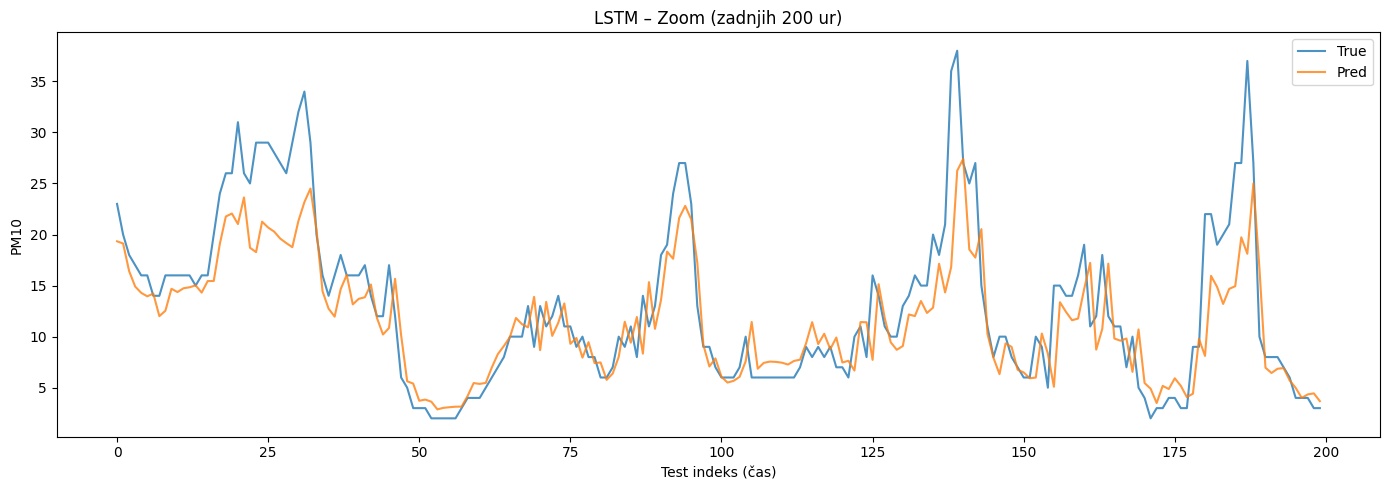

164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step


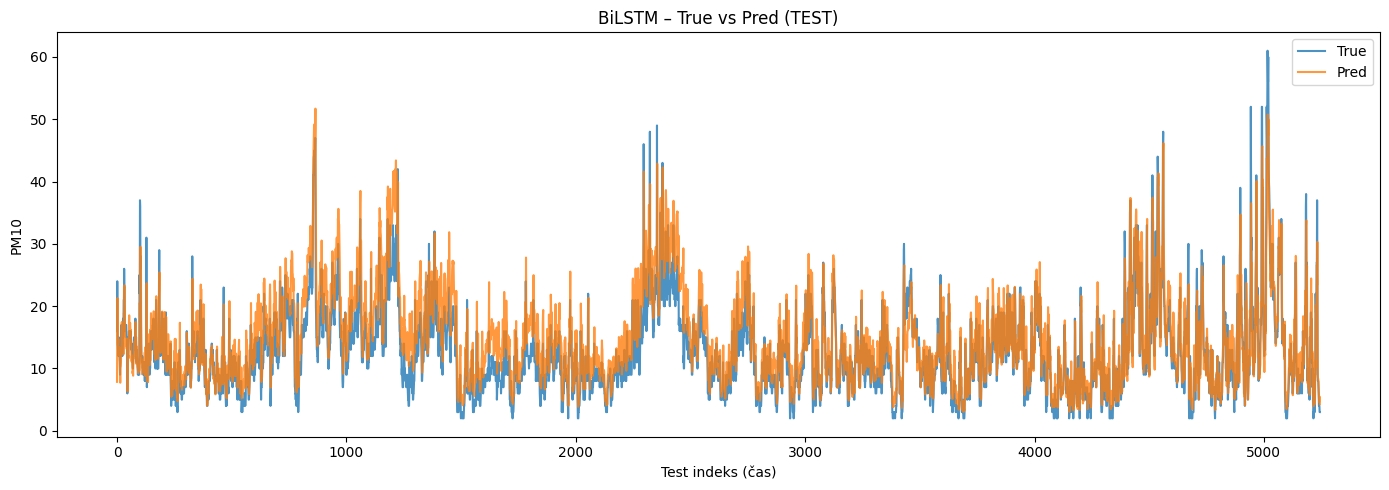

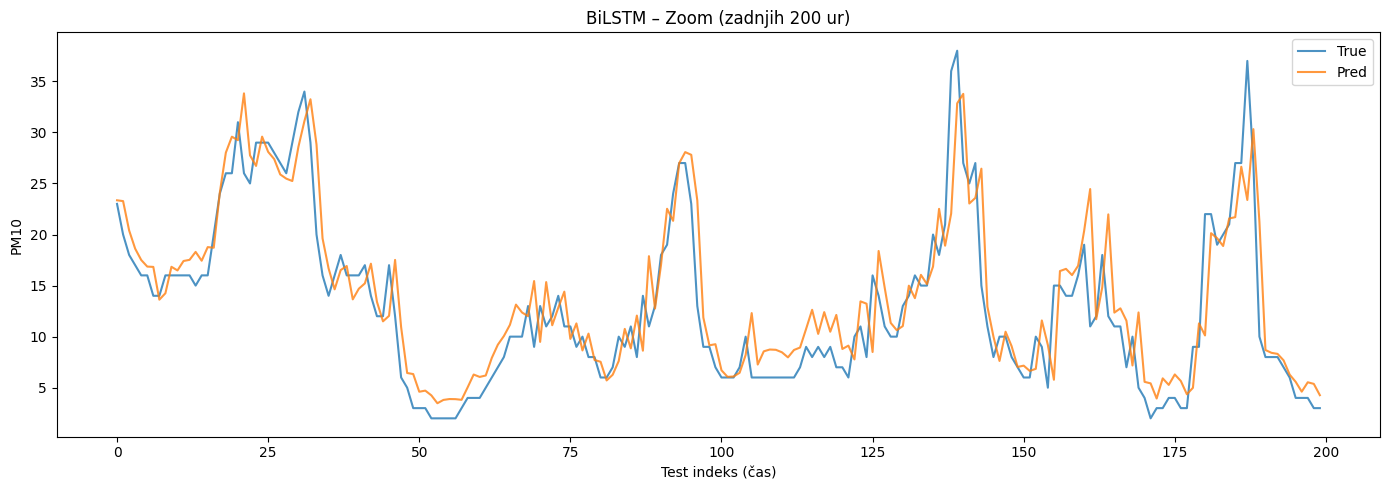

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_predictions(model, name, X_test, y_test_log, n_zoom=200):
    # napoved v log prostoru
    y_pred_log = model.predict(X_test).reshape(-1)

    # nazaj v realni PM10
    y_true = np.expm1(y_test_log.reshape(-1))
    y_pred = np.expm1(y_pred_log)

    plt.figure(figsize=(14,5))
    plt.plot(y_true, label="True", alpha=0.8)
    plt.plot(y_pred, label="Pred", alpha=0.8)
    plt.title(f"{name} – True vs Pred (TEST)")
    plt.xlabel("Test indeks (čas)")
    plt.ylabel("PM10")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # zoom (zadnjih n_zoom točk)
    plt.figure(figsize=(14,5))
    plt.plot(y_true[-n_zoom:], label="True", alpha=0.8)
    plt.plot(y_pred[-n_zoom:], label="Pred", alpha=0.8)
    plt.title(f"{name} – Zoom (zadnjih {n_zoom} ur)")
    plt.xlabel("Test indeks (čas)")
    plt.ylabel("PM10")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_predictions(gru_model, "GRU", X_test_seq, y_test_seq)
plot_predictions(rnn_model, "RNN", X_test_seq, y_test_seq)
plot_predictions(lstm_model, "LSTM", X_test_seq, y_test_seq)
plot_predictions(bilstm_model, "BiLSTM", X_test_seq, y_test_seq)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 1.3582 - val_loss: 0.4357
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1996 - val_loss: 0.1269
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1016 - val_loss: 0.0992
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0851 - val_loss: 0.0955
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0771 - val_loss: 0.0958
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0742 - val_loss: 0.1003
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0714 - val_loss: 0.0972
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0687 - val_loss: 0.1005
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0675 - val_loss: 0.1033


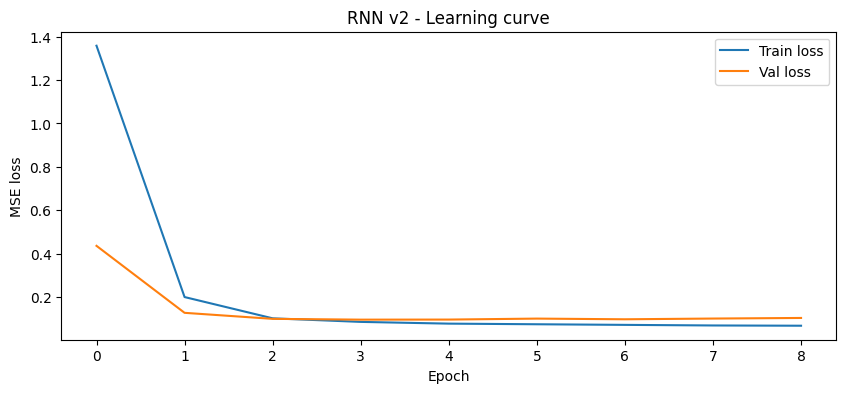

In [28]:
rnn_model_v2 = Sequential([
    Input(shape=input_shape),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32),
    Dense(16, activation="relu"),
    Dense(1)
])

rnn_model_v2.compile(optimizer="adam", loss="mse")

rnn_hist_v2 = train_and_plot_basic(
    rnn_model_v2, "RNN v2",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - loss: 0.7538 - val_loss: 0.2504
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - loss: 0.0928 - val_loss: 0.0941
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - loss: 0.0635 - val_loss: 0.0866
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 28s 121ms/step - loss: 0.0561 - val_loss: 0.0824
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 0.0517 - val_loss: 0.0812
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - loss: 0.0496 - val_loss: 0.0770
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0488 - val_loss: 0.0860
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 0.0478 - val_loss: 0.0837
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 0.0463 - val_loss: 0.0862
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - loss: 0.0467 - val_loss: 0.0805
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - loss: 0.0457 - val_loss: 0.0983


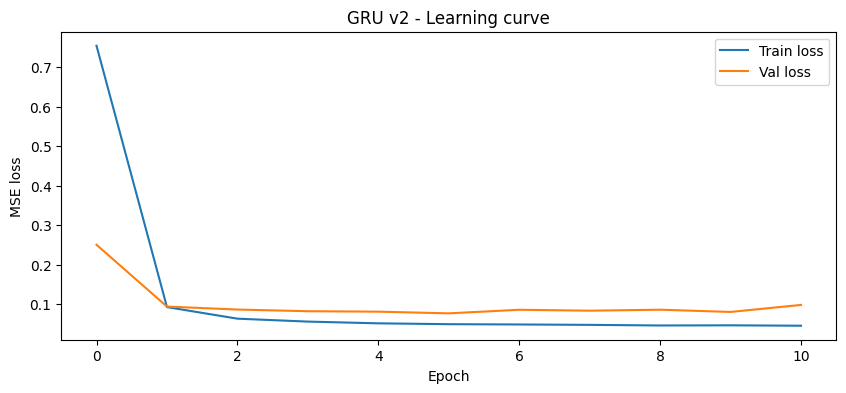

In [29]:
gru_model_v2 = Sequential([
    Input(shape=input_shape),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dense(16, activation="relu"),
    Dense(1)
])

gru_model_v2.compile(optimizer="adam", loss="mse")

gru_hist_v2 = train_and_plot_basic(
    gru_model_v2, "GRU v2",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - loss: 0.6256 - val_loss: 0.1738
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - loss: 0.0933 - val_loss: 0.0931
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - loss: 0.0657 - val_loss: 0.0847
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - loss: 0.0601 - val_loss: 0.0854
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - loss: 0.0592 - val_loss: 0.0820
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - loss: 0.0557 - val_loss: 0.0850
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0547 - val_loss: 0.0871
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 0.0572 - val_loss: 0.0940
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - loss: 0.0564 - val_loss: 0.0837
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 0.0546 - val_loss: 0.0808
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - loss: 0.0501 - val_loss: 0.0787
Epoch 12/25
231/231 ━━━━━━━━━━

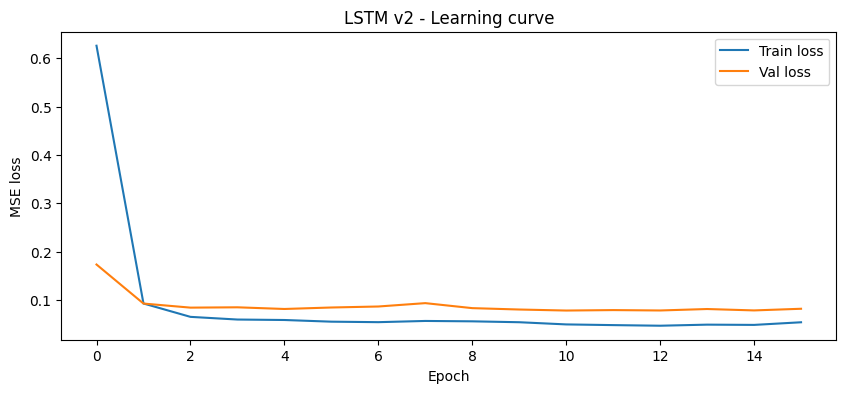

In [30]:
lstm_model_v2 = Sequential([
    Input(shape=input_shape),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model_v2.compile(optimizer="adam", loss="mse")

lstm_hist_v2 = train_and_plot_basic(
    lstm_model_v2, "LSTM v2",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

Epoch 1/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - loss: 0.6788 - val_loss: 0.1773
Epoch 2/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.0760 - val_loss: 0.0873
Epoch 3/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 0.0590 - val_loss: 0.0933
Epoch 4/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.0568 - val_loss: 0.0938
Epoch 5/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - loss: 0.0533 - val_loss: 0.0919
Epoch 6/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - loss: 0.0513 - val_loss: 0.0894
Epoch 7/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - loss: 0.0517 - val_loss: 0.0885


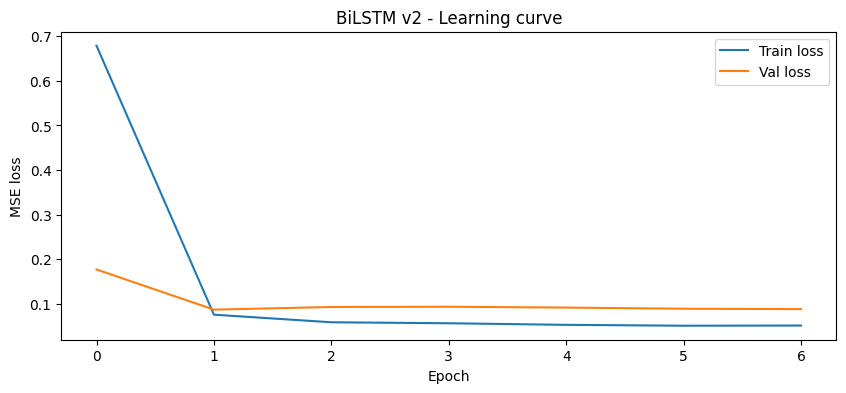

In [31]:
bilstm_model_v2 = Sequential([
    Input(shape=input_shape),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dense(16, activation="relu"),
    Dense(1)
])

bilstm_model_v2.compile(optimizer="adam", loss="mse")

bilstm_hist_v2 = train_and_plot_basic(
    bilstm_model_v2, "BiLSTM v2",
    X_tr, y_tr, X_val, y_val,
    epochs=30, batch_size=32
)

In [32]:
results_v2 = []
results_v2.append(evaluate_model_simple(rnn_model_v2,    "RNN_v2",    X_test_seq, y_test_seq))
results_v2.append(evaluate_model_simple(gru_model_v2,    "GRU_v2",    X_test_seq, y_test_seq))
results_v2.append(evaluate_model_simple(lstm_model_v2,   "LSTM_v2",   X_test_seq, y_test_seq))
results_v2.append(evaluate_model_simple(bilstm_model_v2, "BiLSTM_v2", X_test_seq, y_test_seq))

results_v2_df = pd.DataFrame(results_v2).sort_values("MAE").reset_index(drop=True)
display(results_v2_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step


,Model,MAE,MAPE,MSE,EVS
0,GRU_v2,2.096809,20.117753,8.941994,0.818760
1,RNN_v2,2.199789,20.078907,10.691823,0.781529
2,LSTM_v2,2.293006,20.955600,11.849993,0.766787
3,BiLSTM_v2,2.346667,22.670425,10.500278,0.788719


164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


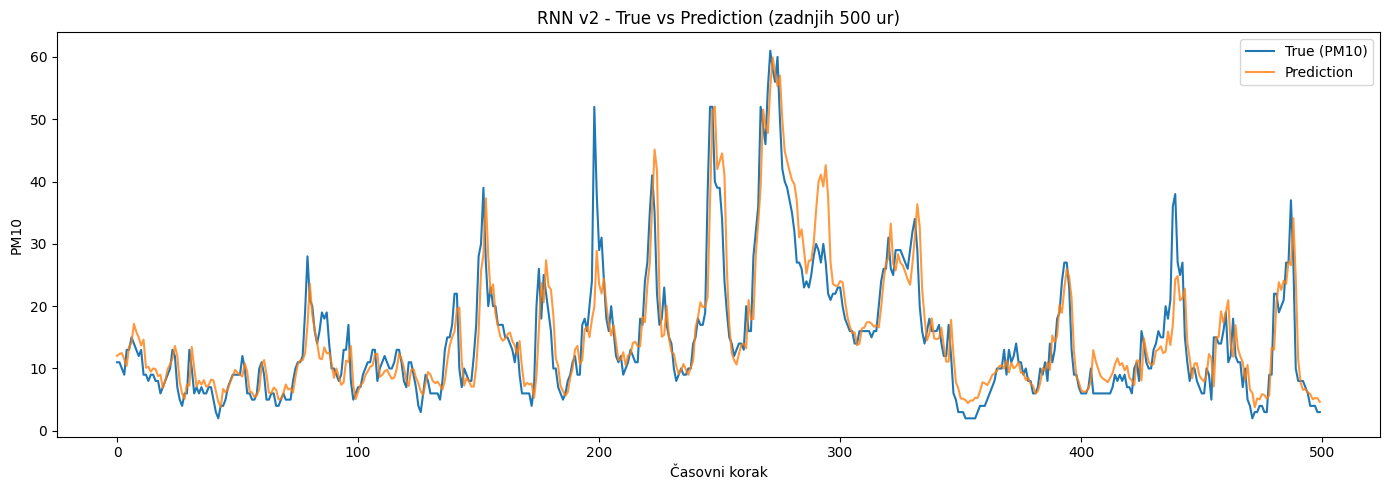

164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step


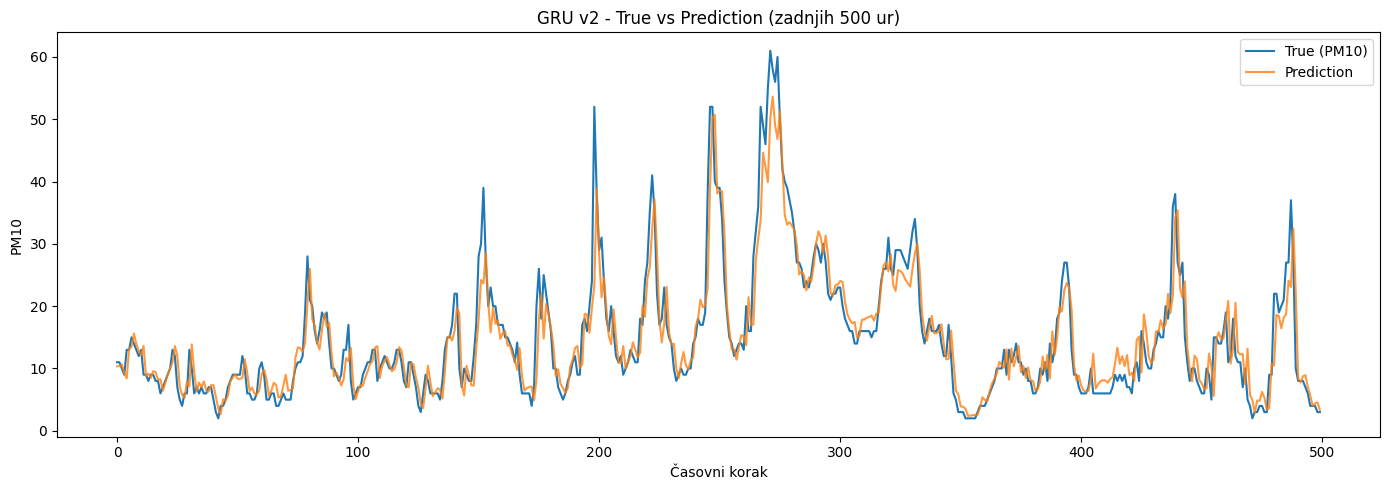

164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step


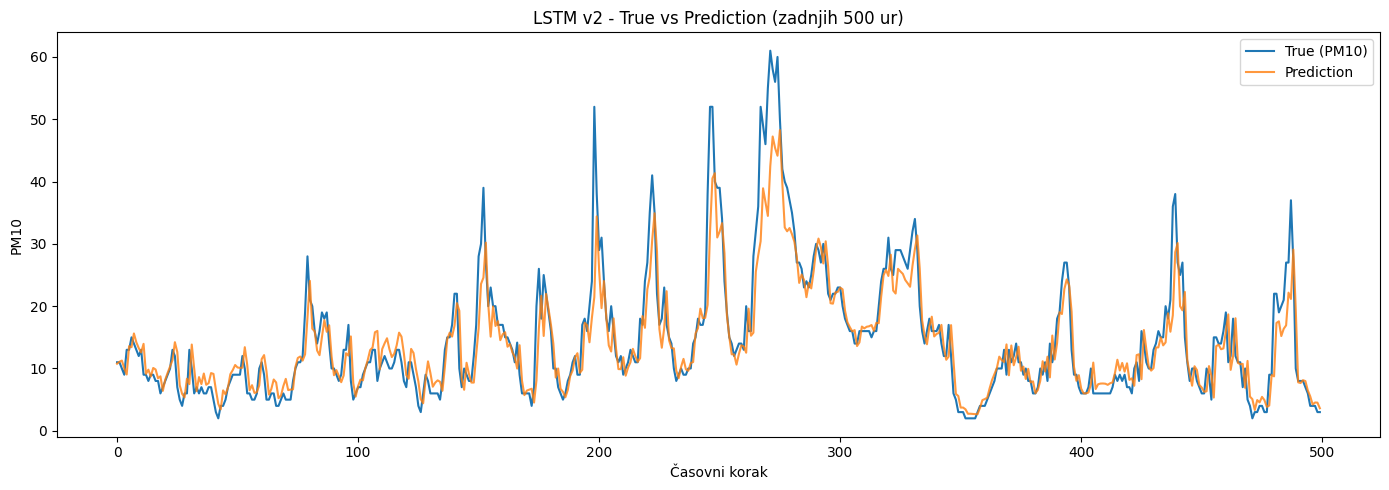

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step


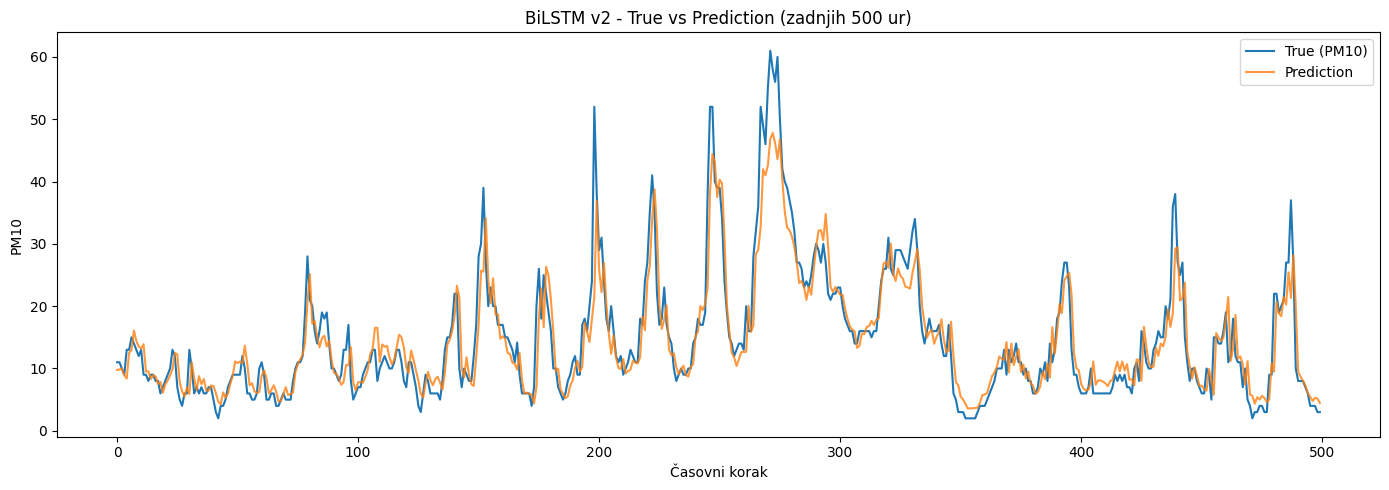

In [33]:
def plot_predictions_real_pm10(model, model_name, X_test, y_test_log, n_last=500):
    # napoved v log prostoru
    y_pred_log = model.predict(X_test).reshape(-1)

    # nazaj v realno PM10 skalo
    y_true = np.expm1(y_test_log.reshape(-1))
    y_pred = np.expm1(y_pred_log)

    # vzamemo samo zadnjih n_last točk
    y_true_plot = y_true[-n_last:]
    y_pred_plot = y_pred[-n_last:]

    plt.figure(figsize=(14,5))
    plt.plot(y_true_plot, label="True (PM10)")
    plt.plot(y_pred_plot, label="Prediction", alpha=0.8)
    plt.title(f"{model_name} - True vs Prediction (zadnjih {n_last} ur)")
    plt.xlabel("Časovni korak")
    plt.ylabel("PM10")
    plt.legend()
    plt.tight_layout()
    plt.show()

# grafi za vse modele
plot_predictions_real_pm10(rnn_model_v2, "RNN v2", X_test_seq, y_test_seq, n_last=500)
plot_predictions_real_pm10(gru_model_v2, "GRU v2", X_test_seq, y_test_seq, n_last=500)
plot_predictions_real_pm10(lstm_model_v2, "LSTM v2", X_test_seq, y_test_seq, n_last=500)
plot_predictions_real_pm10(bilstm_model_v2, "BiLSTM v2", X_test_seq, y_test_seq, n_last=500)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 1.0878 - val_loss: 0.5366
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.3205 - val_loss: 0.1905
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.2122 - val_loss: 0.1596
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.1735 - val_loss: 0.1224
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1496 - val_loss: 0.1318
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.1398 - val_loss: 0.1300
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1271 - val_loss: 0.1374
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.1199 - val_loss: 0.1169
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1346 - val_loss: 0.0973
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.1278 - val_loss: 0.1281
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1304 - val_loss: 0.1101
Epoch 12/25
231/231 ━━━━━━━━━━━━━━━━━━━━

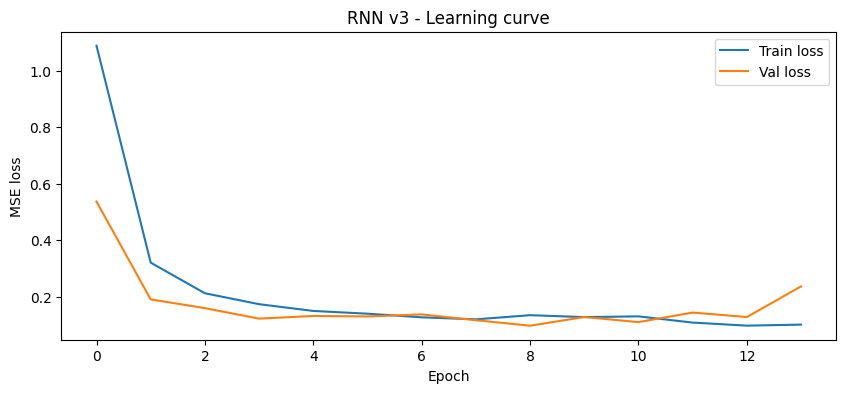

In [34]:
rnn_model_v3 = Sequential([
    Input(shape=input_shape),
    SimpleRNN(64, return_sequences=True),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

rnn_model_v3.compile(optimizer="adam", loss="mse")

rnn_hist_v3 = train_and_plot_basic(
    rnn_model_v3, "RNN v3",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - loss: 1.0148 - val_loss: 0.1373
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - loss: 0.1455 - val_loss: 0.1173
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - loss: 0.1095 - val_loss: 0.0975
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - loss: 0.0951 - val_loss: 0.1041
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - loss: 0.0893 - val_loss: 0.0942
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - loss: 0.0830 - val_loss: 0.0834
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - loss: 0.0848 - val_loss: 0.0973
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - loss: 0.0794 - val_loss: 0.0963
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - loss: 0.0754 - val_loss: 0.1027
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - loss: 0.0743 - val_loss: 0.0975
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - loss: 0.0820 - val_loss: 0.1212


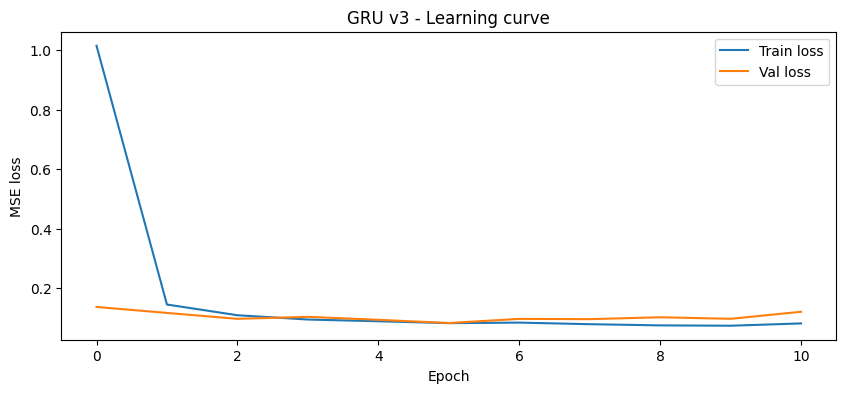

In [35]:
gru_model_v3 = Sequential([
    Input(shape=input_shape),
    GRU(64, return_sequences=True),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model_v3.compile(optimizer="adam", loss="mse")

gru_hist_v3 = train_and_plot_basic(
    gru_model_v3, "GRU v3",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 28s 98ms/step - loss: 1.0168 - val_loss: 0.3139
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - loss: 0.1366 - val_loss: 0.0987
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - loss: 0.0975 - val_loss: 0.0912
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 0.0896 - val_loss: 0.0877
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - loss: 0.0822 - val_loss: 0.0960
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - loss: 0.0786 - val_loss: 0.0839
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - loss: 0.0757 - val_loss: 0.0790
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - loss: 0.0769 - val_loss: 0.0804
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - loss: 0.0728 - val_loss: 0.0907
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - loss: 0.0801 - val_loss: 0.0827
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - loss: 0.0818 - val_loss: 0.0980
Epoch 12/25
231/231 ━━━━━━━

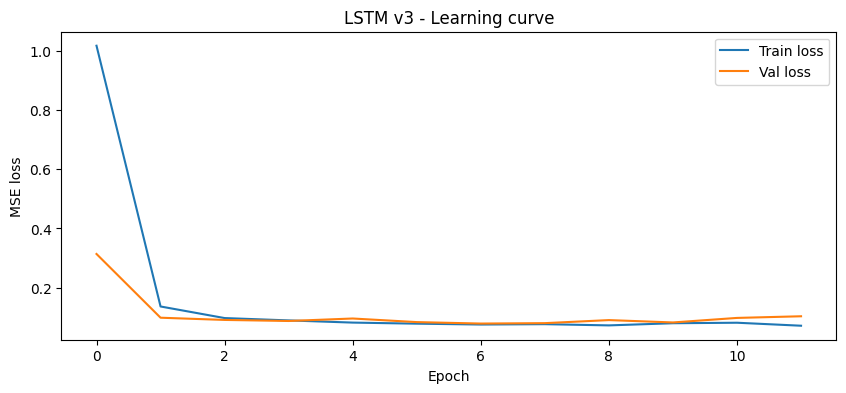

In [36]:
lstm_model_v3 = Sequential([
    Input(shape=input_shape),
    LSTM(64, return_sequences=True),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_v3.compile(optimizer="adam", loss="mse")

lstm_hist_v3 = train_and_plot_basic(
    lstm_model_v3, "LSTM v3",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - loss: 0.7103 - val_loss: 0.3466
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.1230 - val_loss: 0.0974
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.0949 - val_loss: 0.0943
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.0872 - val_loss: 0.1003
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - loss: 0.0811 - val_loss: 0.0902
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.0718 - val_loss: 0.0924
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - loss: 0.0698 - val_loss: 0.1320
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0703 - val_loss: 0.1596
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - loss: 0.0841 - val_loss: 0.1214
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - loss: 0.0737 - val_loss: 0.1178


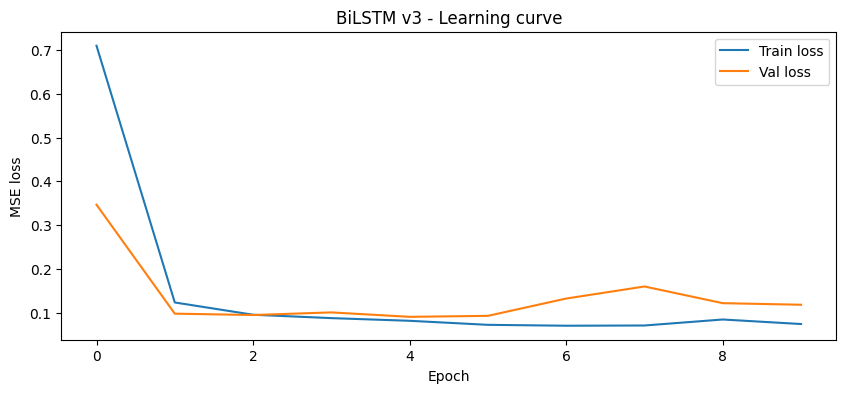

In [37]:
bilstm_model_v3 = Sequential([
    Input(shape=input_shape),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

bilstm_model_v3.compile(optimizer="adam", loss="mse")

bilstm_hist_v3 = train_and_plot_basic(
    bilstm_model_v3, "BiLSTM v3",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=32
)

In [38]:
results_v3 = []
results_v3.append(evaluate_model_simple(rnn_model_v3, "RNN_v3", X_test_seq, y_test_seq))
results_v3.append(evaluate_model_simple(gru_model_v3, "GRU_v3", X_test_seq, y_test_seq))
results_v3.append(evaluate_model_simple(lstm_model_v3, "LSTM_v3", X_test_seq, y_test_seq))
results_v3.append(evaluate_model_simple(bilstm_model_v3, "BiLSTM_v3", X_test_seq, y_test_seq))

results_v3_df = pd.DataFrame(results_v3).sort_values("MAE").reset_index(drop=True)
display(results_v3_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step


,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3,2.084748,18.422032,9.774517,0.800047
1,GRU_v3,2.152962,18.230595,10.474595,0.787223
2,BiLSTM_v3,2.442838,21.416807,13.763657,0.729666
3,RNN_v3,2.533667,24.357826,11.942162,0.765117


In [39]:
all_results = []

# osnovni modeli
all_results.append(evaluate_model_simple(rnn_model, "RNN", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(gru_model, "GRU", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(lstm_model, "LSTM", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(bilstm_model, "BiLSTM", X_test_seq, y_test_seq))

# v2 modeli
all_results.append(evaluate_model_simple(rnn_model_v2, "RNN_v2", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(gru_model_v2, "GRU_v2", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(lstm_model_v2, "LSTM_v2", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(bilstm_model_v2, "BiLSTM_v2", X_test_seq, y_test_seq))

# v3 modeli
all_results.append(evaluate_model_simple(rnn_model_v3, "RNN_v3", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(gru_model_v3, "GRU_v3", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(lstm_model_v3, "LSTM_v3", X_test_seq, y_test_seq))
all_results.append(evaluate_model_simple(bilstm_model_v3, "BiLSTM_v3", X_test_seq, y_test_seq))

# tabela + sortiranje
all_results_df = pd.DataFrame(all_results).sort_values("MAE").reset_index(drop=True)
display(all_results_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step


,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3,2.084748,18.422032,9.774517,0.800047
1,GRU_v2,2.096809,20.117753,8.941994,0.818760
2,GRU_v3,2.152962,18.230595,10.474595,0.787223
3,RNN_v2,2.199789,20.078907,10.691823,0.781529
4,GRU,2.248787,21.269427,10.477761,0.787349
5,LSTM_v2,2.293006,20.955600,11.849993,0.766787
6,BiLSTM_v2,2.346667,22.670425,10.500278,0.788719
7,BiLSTM_v3,2.442838,21.416807,13.763657,0.729666
8,RNN,2.525113,23.290272,13.074666,0.732979
9,RNN_v3,2.533667,24.357826,11.942162,0.765117




===== LSTM_v3 | batch_size=16 =====
Epoch 1/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - loss: 0.4063 - val_loss: 0.3191
Epoch 2/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - loss: 0.1725 - val_loss: 0.1218
Epoch 3/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - loss: 0.1356 - val_loss: 0.1086
Epoch 4/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 0.0875 - val_loss: 0.0841
Epoch 5/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 0.0769 - val_loss: 0.0934
Epoch 6/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - loss: 0.0764 - val_loss: 0.0872
Epoch 7/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 45s 97ms/step - loss: 0.0726 - val_loss: 0.0900
Epoch 8/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 96ms/step - loss: 0.0713 - val_loss: 0.1079
Epoch 9/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 45s 97ms/step - loss: 0.0689 - val_loss: 0.1260


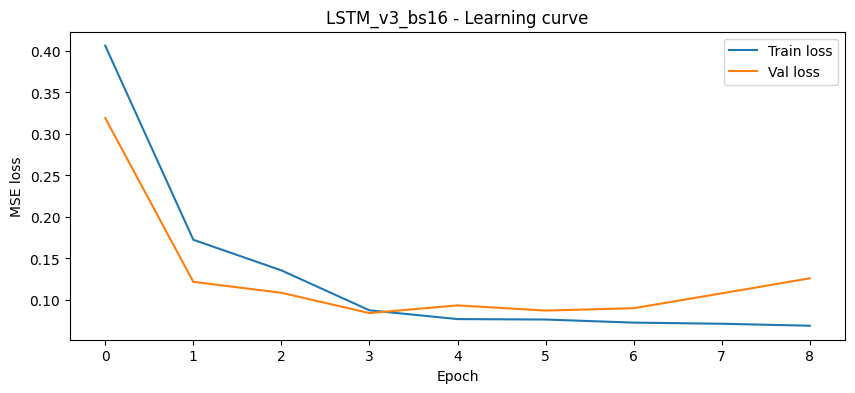

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step

===== LSTM_v3 | batch_size=32 =====
Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 33s 119ms/step - loss: 0.6843 - val_loss: 0.1402
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.1360 - val_loss: 0.0994
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - loss: 0.1043 - val_loss: 0.0845
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - loss: 0.0929 - val_loss: 0.0847
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - loss: 0.0851 - val_loss: 0.0800
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - loss: 0.0803 - val_loss: 0.0809
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 0.0857 - val_loss: 0.0861
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - loss: 0.0791 - val_loss: 0.0794
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - loss: 0.0771 - val_loss: 0.0966
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - loss: 0.0763 - val_loss: 0.0848
Epoch 11/25
231/231 ━━━━━━━━━━━

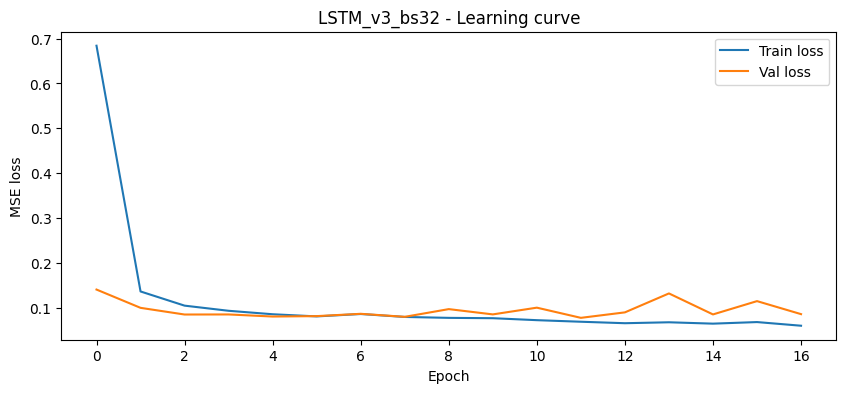

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step

===== LSTM_v3 | batch_size=64 =====
Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - loss: 1.6930 - val_loss: 0.3082
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.2156 - val_loss: 0.1687
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.1400 - val_loss: 0.1248
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - loss: 0.1120 - val_loss: 0.1094
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - loss: 0.0966 - val_loss: 0.0975
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - loss: 0.0902 - val_loss: 0.0914
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - loss: 0.0882 - val_loss: 0.0940
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - loss: 0.0838 - val_loss: 0.0890
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - loss: 0.0795 - val_loss: 0.0870
Epoch 10/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 0.0797 - val_loss: 0.0991
Epoch 11/25
116/116 ━━━━━━━━━━

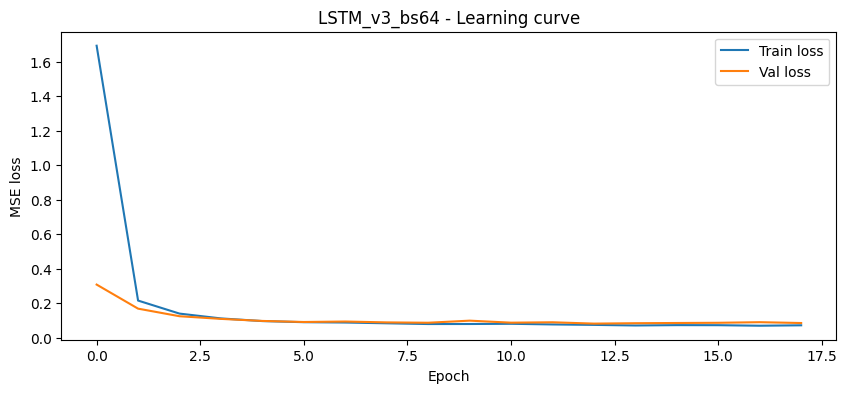

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step


,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3_bs64,1.960975,18.144285,8.519676,0.825642
1,LSTM_v3_bs32,2.043473,18.991554,9.132171,0.812271
2,LSTM_v3_bs16,2.176325,20.818817,9.357332,0.807690


In [40]:
# preizskus razlicnih batch sizov za naj modela lstm v3 in gru v2

batch_sizes = [16, 32, 64]

lstm_v3_bs_models = {}
lstm_v3_bs_results = []

for bs in batch_sizes:
    tf.keras.backend.clear_session()

    lstm_model_v3_bs = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    lstm_model_v3_bs.compile(optimizer="adam", loss="mse")

    print(f"\n===== LSTM_v3 | batch_size={bs} =====")
    train_and_plot_basic(
        lstm_model_v3_bs, f"LSTM_v3_bs{bs}",
        X_tr, y_tr, X_val, y_val,
        epochs=25, batch_size=bs
    )

    lstm_v3_bs_models[bs] = lstm_model_v3_bs
    lstm_v3_bs_results.append(
        evaluate_model_simple(lstm_model_v3_bs, f"LSTM_v3_bs{bs}", X_test_seq, y_test_seq)
    )

lstm_v3_bs_df = pd.DataFrame(lstm_v3_bs_results).sort_values("MAE").reset_index(drop=True)
display(lstm_v3_bs_df)


===== GRU_v2 | batch_size=16 =====
Epoch 1/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - loss: 0.6037 - val_loss: 0.1461
Epoch 2/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - loss: 0.0855 - val_loss: 0.0981
Epoch 3/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 47s 102ms/step - loss: 0.0673 - val_loss: 0.0857
Epoch 4/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0624 - val_loss: 0.0907
Epoch 5/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 46s 101ms/step - loss: 0.0591 - val_loss: 0.0918
Epoch 6/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - loss: 0.0571 - val_loss: 0.1034
Epoch 7/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 46s 100ms/step - loss: 0.0570 - val_loss: 0.1096
Epoch 8/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0557 - val_loss: 0.0972


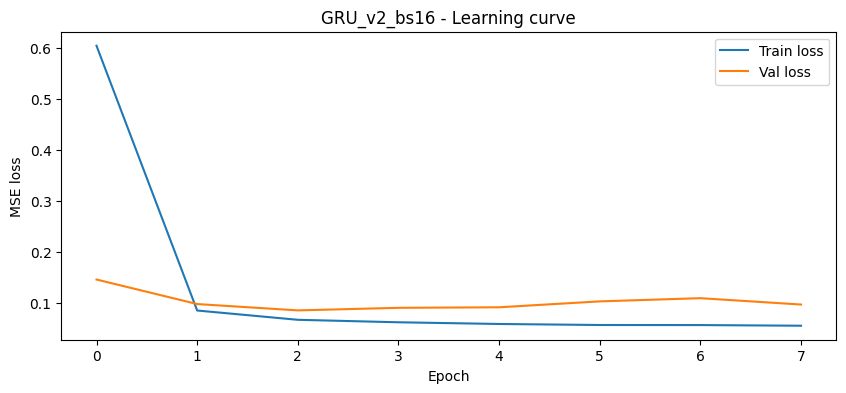

164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step

===== GRU_v2 | batch_size=32 =====
Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step - loss: 0.9367 - val_loss: 0.3515
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - loss: 0.0950 - val_loss: 0.0918
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - loss: 0.0625 - val_loss: 0.0841
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - loss: 0.0558 - val_loss: 0.0819
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - loss: 0.0520 - val_loss: 0.0788
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - loss: 0.0515 - val_loss: 0.0785
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - loss: 0.0496 - val_loss: 0.0750
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - loss: 0.0531 - val_loss: 0.0808
Epoch 9/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 0.0484 - val_loss: 0.0769
Epoch 10/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - loss: 0.0547 - val_loss: 0.0807
Epoch 11/25
231/231 ━━━━━━━━━━━━━━━━

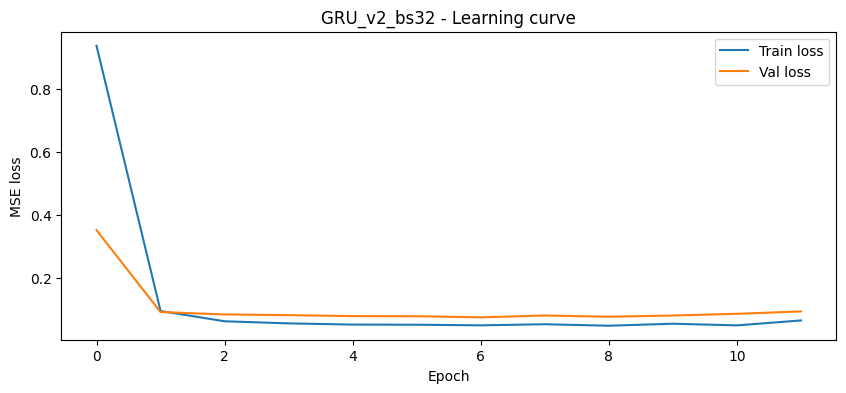

164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step

===== GRU_v2 | batch_size=64 =====
Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - loss: 1.6466 - val_loss: 0.8731
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - loss: 0.2972 - val_loss: 0.2552
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.1093 - val_loss: 0.1466
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 0.0780 - val_loss: 0.1105
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0661 - val_loss: 0.0969
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - loss: 0.0603 - val_loss: 0.0931
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - loss: 0.0589 - val_loss: 0.0919
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - loss: 0.0556 - val_loss: 0.0886
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - loss: 0.0532 - val_loss: 0.0831
Epoch 10/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0526 - val_loss: 0.0840
Epoch 11/25
116/116 ━━━━━━━━━━━━━

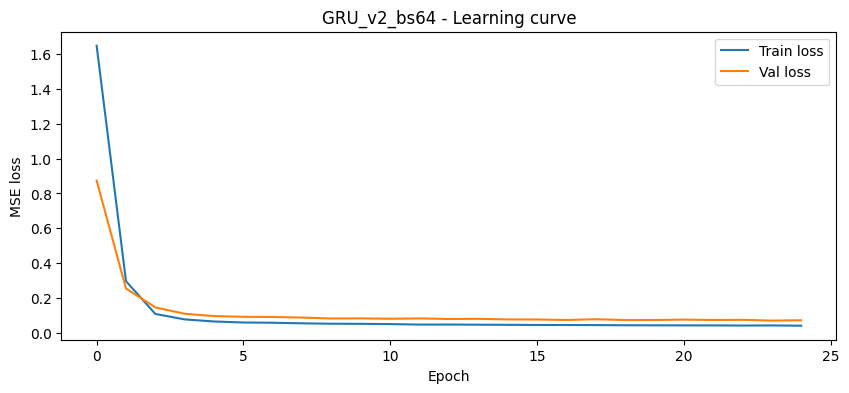

164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


,Model,MAE,MAPE,MSE,EVS
0,GRU_v2_bs32,2.128683,20.236867,9.525353,0.805709
1,GRU_v2_bs16,2.141872,19.375784,9.608448,0.802153
2,GRU_v2_bs64,2.796944,25.098463,15.357577,0.742705


In [41]:
batch_sizes = [16, 32, 64]

gru_v2_bs_models = {}
gru_v2_bs_results = []

for bs in batch_sizes:
    tf.keras.backend.clear_session()

    gru_model_v2_bs = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    gru_model_v2_bs.compile(optimizer="adam", loss="mse")

    print(f"\n===== GRU_v2 | batch_size={bs} =====")
    train_and_plot_basic(
        gru_model_v2_bs, f"GRU_v2_bs{bs}",
        X_tr, y_tr, X_val, y_val,
        epochs=25, batch_size=bs
    )

    gru_v2_bs_models[bs] = gru_model_v2_bs
    gru_v2_bs_results.append(
        evaluate_model_simple(gru_model_v2_bs, f"GRU_v2_bs{bs}", X_test_seq, y_test_seq)
    )

gru_v2_bs_df = pd.DataFrame(gru_v2_bs_results).sort_values("MAE").reset_index(drop=True)
display(gru_v2_bs_df)

In [42]:
all_bs_df = pd.concat([lstm_v3_bs_df, gru_v2_bs_df], ignore_index=True)
all_bs_df = all_bs_df.sort_values("MAE").reset_index(drop=True)

display(all_bs_df)

best_lstm_bs = int(lstm_v3_bs_df.loc[0, "Model"].split("bs")[-1])
best_gru_bs  = int(gru_v2_bs_df.loc[0, "Model"].split("bs")[-1])

best_lstm_model = lstm_v3_bs_models[best_lstm_bs]
best_gru_model  = gru_v2_bs_models[best_gru_bs]

print("Najboljši LSTM_v3 batch:", best_lstm_bs)
print("Najboljši GRU_v2 batch :", best_gru_bs)

,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3_bs64,1.960975,18.144285,8.519676,0.825642
1,LSTM_v3_bs32,2.043473,18.991554,9.132171,0.812271
2,GRU_v2_bs32,2.128683,20.236867,9.525353,0.805709
3,GRU_v2_bs16,2.141872,19.375784,9.608448,0.802153
4,LSTM_v3_bs16,2.176325,20.818817,9.357332,0.807690
5,GRU_v2_bs64,2.796944,25.098463,15.357577,0.742705


Najboljši LSTM_v3 batch: 64
Najboljši GRU_v2 batch : 32


164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


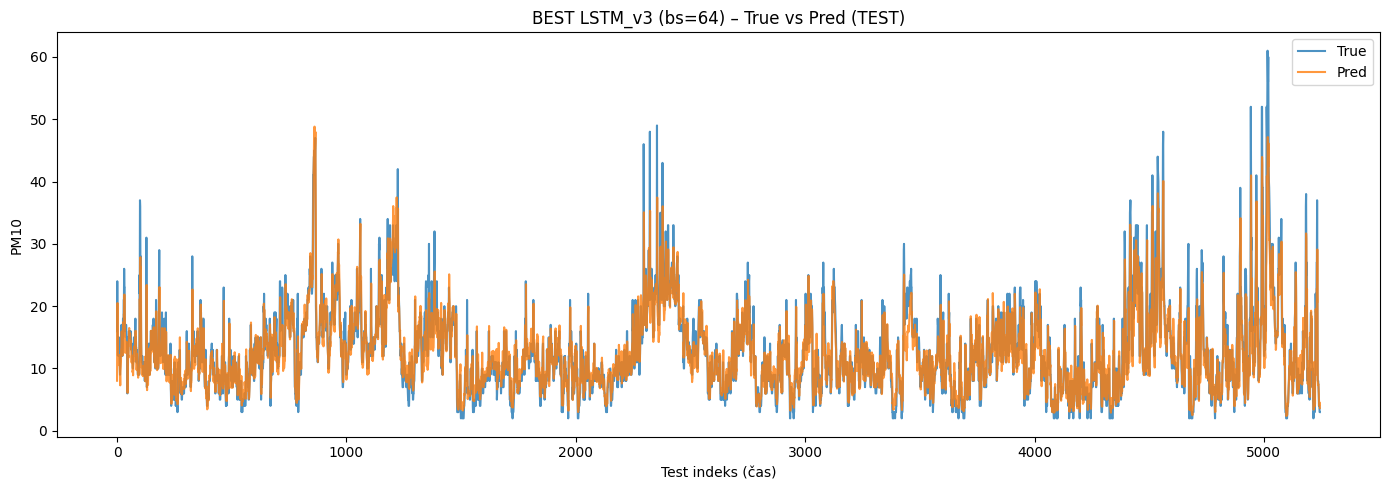

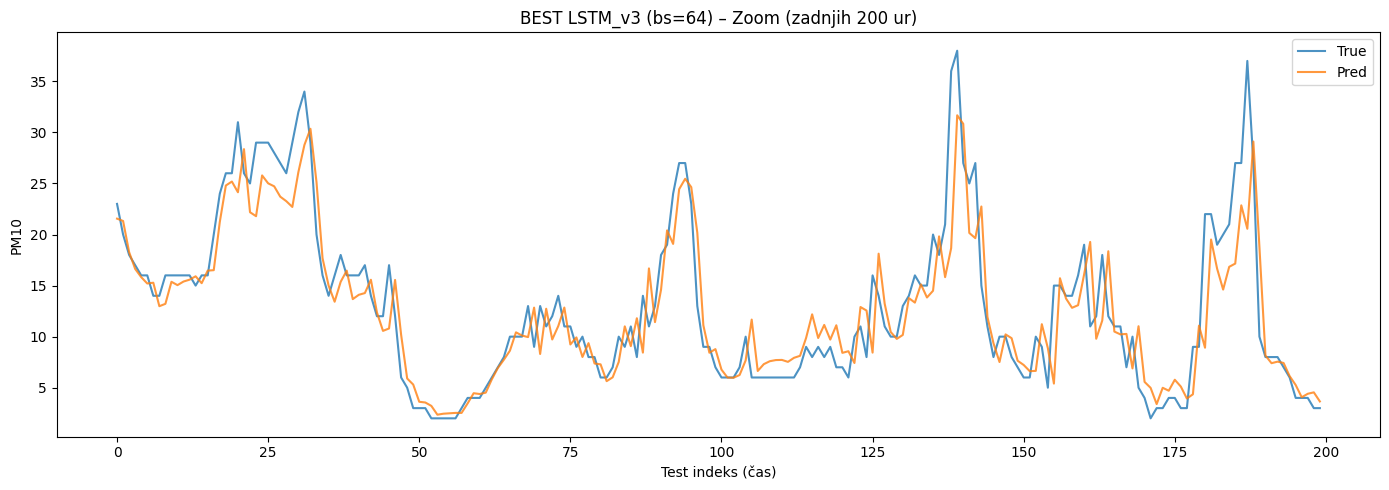

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


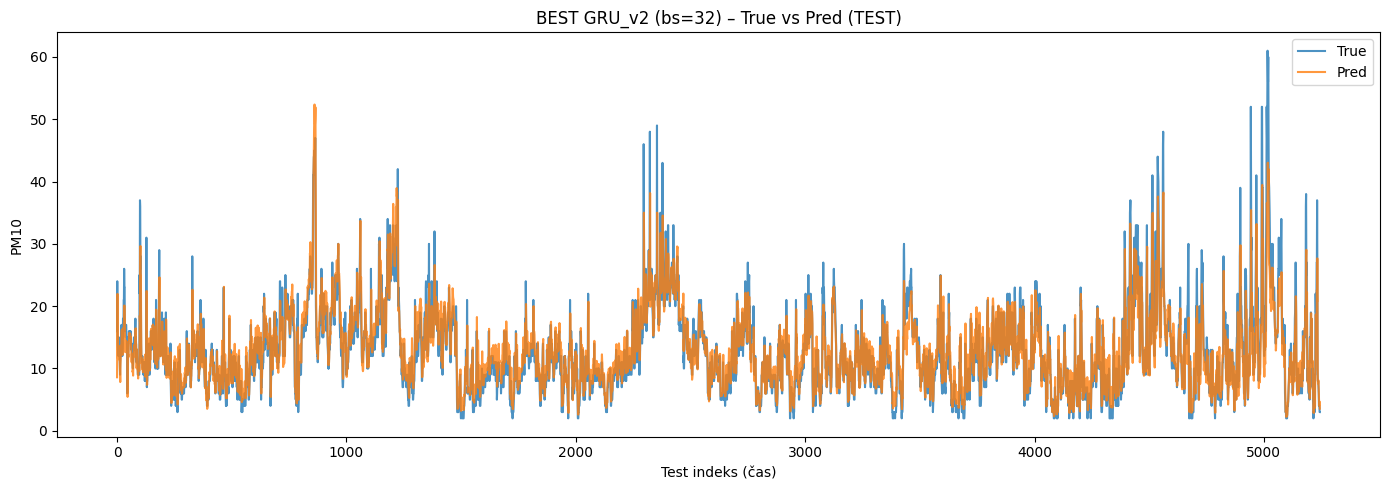

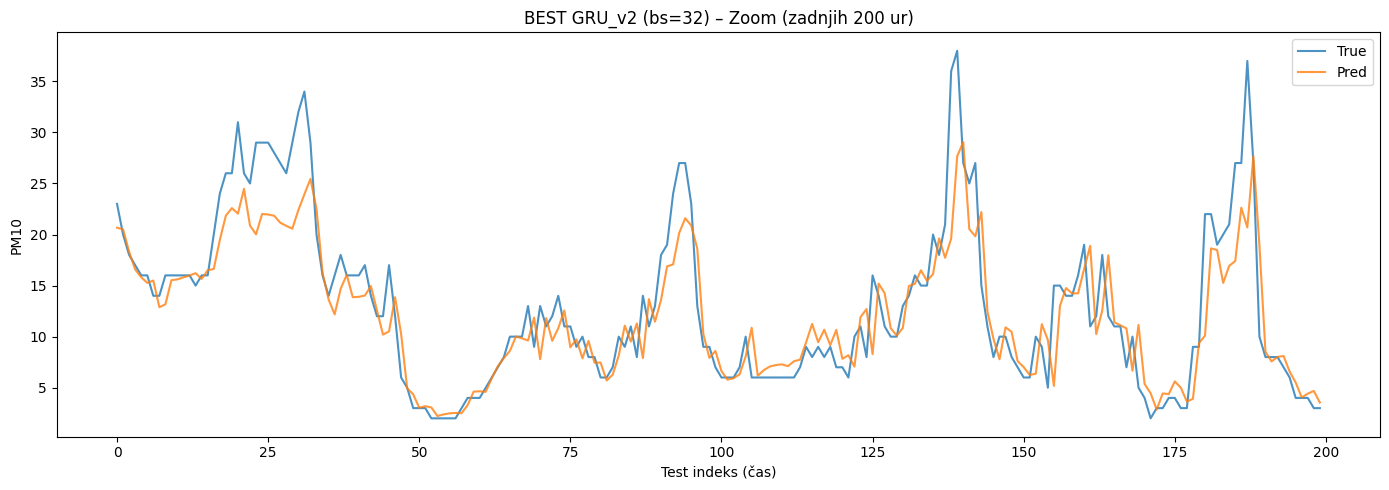

In [44]:
plot_predictions(best_lstm_model, f"BEST LSTM_v3 (bs={best_lstm_bs})", X_test_seq, y_test_seq)
plot_predictions(best_gru_model,  f"BEST GRU_v2 (bs={best_gru_bs})",  X_test_seq, y_test_seq)

Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - loss: 0.5749 - val_loss: 0.1628
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - loss: 0.1376 - val_loss: 0.1360
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.1031 - val_loss: 0.0921
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 0.0896 - val_loss: 0.0851
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0844 - val_loss: 0.0891
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0764 - val_loss: 0.0777
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0773 - val_loss: 0.0770
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0723 - val_loss: 0.1162
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - loss: 0.0726 - val_loss: 0.1147
Epoch 10/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0693 - val_loss: 0.0854
Epoch 11/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0684 - val_loss: 0.0965
Epoch 12/25
116/116 ━━━━━━━━━━━━

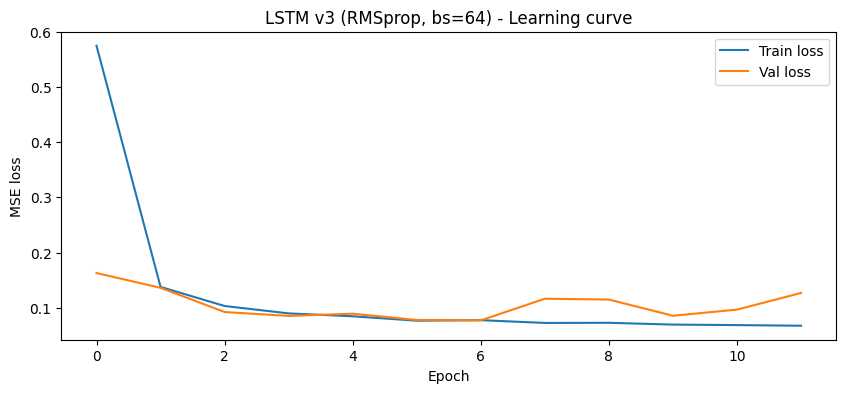

In [45]:
from tensorflow.keras.optimizers import RMSprop

lstm_model_v3_rmsprop = Sequential([
    Input(shape=input_shape),
    LSTM(64, return_sequences=True),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_v3_rmsprop.compile(optimizer=RMSprop(), loss="mse")

lstm_hist_v3_rmsprop = train_and_plot_basic(
    lstm_model_v3_rmsprop, "LSTM v3 (RMSprop, bs=64)",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=64
)

In [51]:
results_opt = []

results_opt.append(evaluate_model_simple(best_lstm_model, "LSTM_v3 (Adam)", X_test_seq, y_test_seq))
results_opt.append(evaluate_model_simple(lstm_model_v3_rmsprop, "LSTM_v3 (RMSprop)", X_test_seq, y_test_seq))

results_opt_df = pd.DataFrame(results_opt).sort_values("MAE").reset_index(drop=True)
display(results_opt_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step


,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3 (Adam),1.960975,18.144285,8.519676,0.825642
1,LSTM_v3 (RMSprop),2.106483,18.403897,9.951132,0.797690


Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 28s 133ms/step - loss: 0.8256 - val_loss: 0.2679
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.1615 - val_loss: 0.1337
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.1098 - val_loss: 0.1135
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - loss: 0.0934 - val_loss: 0.1010
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0828 - val_loss: 0.1078
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - loss: 0.0767 - val_loss: 0.1094
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step - loss: 0.0740 - val_loss: 0.1109
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0701 - val_loss: 0.1162
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0681 - val_loss: 0.1251


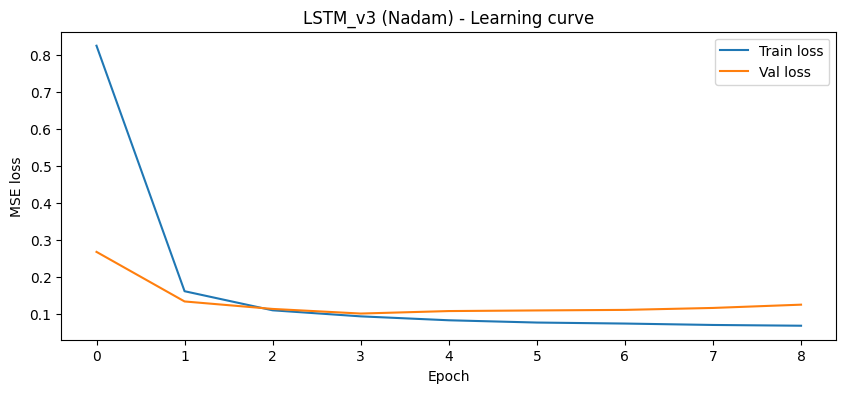

Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - loss: 2.7072 - val_loss: 1.9264
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.4415 - val_loss: 0.3967
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - loss: 0.3039 - val_loss: 0.1990
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - loss: 0.2420 - val_loss: 0.1595
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 139ms/step - loss: 0.1966 - val_loss: 0.1502
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - loss: 0.1791 - val_loss: 0.1437
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.1629 - val_loss: 0.1311
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.1566 - val_loss: 0.1295
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - loss: 0.1425 - val_loss: 0.1201
Epoch 10/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.1324 - val_loss: 0.1150
Epoch 11/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step - loss: 0.1255 - val_loss: 0.1105
Epoch 12/25
116/116 

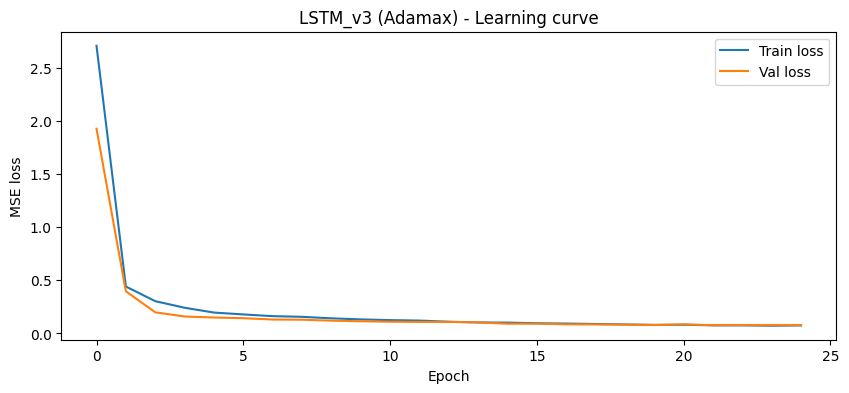

164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step


,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3 (Adam),1.960975,18.144285,8.519676,0.825642
1,LSTM_v3 (RMSprop),2.106483,18.403897,9.951132,0.797690
2,LSTM_v3 (Adamax),2.226886,21.267338,10.277516,0.790132
3,LSTM_v3 (Nadam),2.305523,20.337505,12.062752,0.771923


In [53]:
# še dve optimizerja nadam in adamax na lstm v3

from tensorflow.keras.optimizers import Nadam, Adamax

def build_lstm_v3(optimizer):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss="mse")
    return model

# Nadam
lstm_model_v3_nadam = build_lstm_v3(Nadam())
train_and_plot_basic(lstm_model_v3_nadam, "LSTM_v3 (Nadam)", X_tr, y_tr, X_val, y_val, epochs=25, batch_size=64)

# Adamax
lstm_model_v3_adamax = build_lstm_v3(Adamax())
train_and_plot_basic(lstm_model_v3_adamax, "LSTM_v3 (Adamax)", X_tr, y_tr, X_val, y_val, epochs=25, batch_size=64)

# Eval tabela
results_opt2 = []
results_opt2.append(evaluate_model_simple(best_lstm_model, "LSTM_v3 (Adam)", X_test_seq, y_test_seq))
results_opt2.append(evaluate_model_simple(lstm_model_v3_rmsprop, "LSTM_v3 (RMSprop)", X_test_seq, y_test_seq))
results_opt2.append(evaluate_model_simple(lstm_model_v3_nadam, "LSTM_v3 (Nadam)", X_test_seq, y_test_seq))
results_opt2.append(evaluate_model_simple(lstm_model_v3_adamax, "LSTM_v3 (Adamax)", X_test_seq, y_test_seq))

results_opt2_df = pd.DataFrame(results_opt2).sort_values("MAE").reset_index(drop=True)
display(results_opt2_df)

Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 38s 219ms/step - loss: 2.2566 - val_loss: 0.4489
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - loss: 0.2625 - val_loss: 0.2184
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.1981 - val_loss: 0.1801
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.1582 - val_loss: 0.1489
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - loss: 0.1334 - val_loss: 0.1253
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 0.1209 - val_loss: 0.1155
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.1080 - val_loss: 0.1030
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.0984 - val_loss: 0.1133
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0925 - val_loss: 0.0990
Epoch 10/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 0.0875 - val_loss: 0.0938
Epoch 11/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0870 - val_loss: 0.0981
Epoch 12/25
116/116 ━━━━━━━━━━━━━━

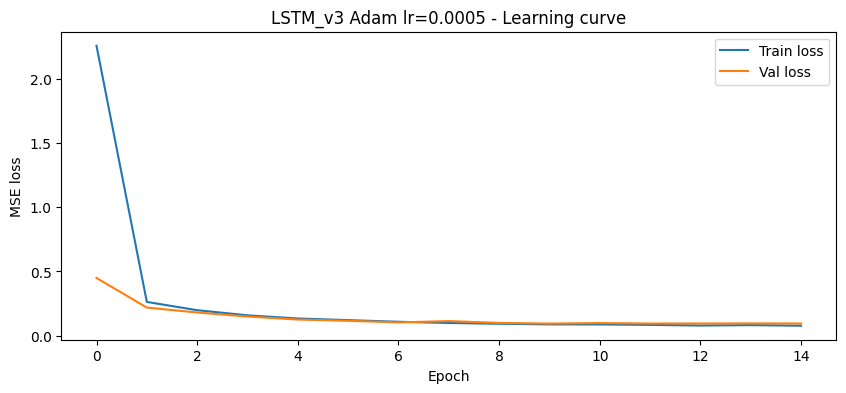

In [54]:
# NOV model: isti kot LSTM_v3, samo learning_rate=0.0005
lstm_model_v3_lr0005 = Sequential([
    Input(shape=input_shape),
    LSTM(64, return_sequences=True),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_v3_lr0005.compile(optimizer=Adam(learning_rate=0.0005), loss="mse")

# treniranje (isti batch kot najboljsi: 64)
lstm_hist_v3_lr0005 = train_and_plot_basic(
    lstm_model_v3_lr0005, "LSTM_v3 Adam lr=0.0005",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=64
)

In [55]:
results_lr = []

results_lr.append(evaluate_model_simple(best_lstm_model, "LSTM_v3 Adam lr=0.001 (baseline)", X_test_seq, y_test_seq))
results_lr.append(evaluate_model_simple(lstm_model_v3_lr0005, "LSTM_v3 Adam lr=0.0005", X_test_seq, y_test_seq))

results_lr_df = pd.DataFrame(results_lr).sort_values("MAE").reset_index(drop=True)
display(results_lr_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


,Model,MAE,MAPE,MSE,EVS
0,LSTM_v3 Adam lr=0.001 (baseline),1.960975,18.144285,8.519676,0.825642
1,LSTM_v3 Adam lr=0.0005,2.236811,20.913879,10.030069,0.798110


Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 206ms/step - loss: 1.4908 - val_loss: 0.5174
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - loss: 0.2702 - val_loss: 0.1602
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 27s 229ms/step - loss: 0.1669 - val_loss: 0.1309
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 28s 237ms/step - loss: 0.1360 - val_loss: 0.1121
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - loss: 0.1231 - val_loss: 0.1085
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - loss: 0.1072 - val_loss: 0.1133
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - loss: 0.1019 - val_loss: 0.1189
Epoch 8/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.0986 - val_loss: 0.1009
Epoch 9/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - loss: 0.0920 - val_loss: 0.1151
Epoch 10/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step - loss: 0.0919 - val_loss: 0.1171
Epoch 11/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step - loss: 0.0865 - val_loss: 0.1351
Epoch 12/25
116/116

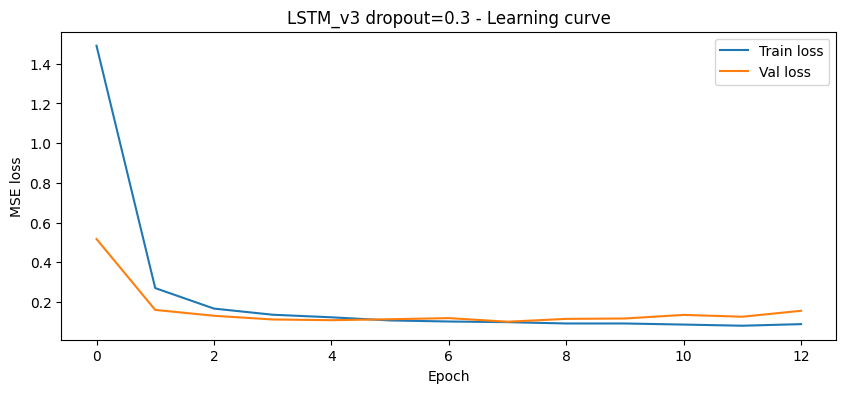

In [58]:
lstm_model_v3_do03 = Sequential([
    Input(shape=input_shape),
    LSTM(64, return_sequences=True),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_v3_do03.compile(optimizer=Adam(), loss="mse")

hist_lstm_v3_do03 = train_and_plot_basic(
    lstm_model_v3_do03, "LSTM_v3 dropout=0.3",
    X_tr, y_tr, X_val, y_val,
    epochs=25, batch_size=64
)

In [59]:
results_final_try = []
results_final_try.append(evaluate_model_simple(best_lstm_model, "BEST baseline (LSTM_v3)", X_test_seq, y_test_seq))
results_final_try.append(evaluate_model_simple(lstm_model_v3_do03, "LSTM_v3 dropout=0.3", X_test_seq, y_test_seq))

results_final_try_df = pd.DataFrame(results_final_try).sort_values("MAE").reset_index(drop=True)
display(results_final_try_df)

164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step


,Model,MAE,MAPE,MSE,EVS
0,BEST baseline (LSTM_v3),1.960975,18.144285,8.519676,0.825642
1,LSTM_v3 dropout=0.3,2.218034,18.501189,10.978129,0.805322


164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step
FINAL LSTM (best) - MAE: 1.961, MSE: 8.520, EVS: 0.826, MAPE: 18.14%


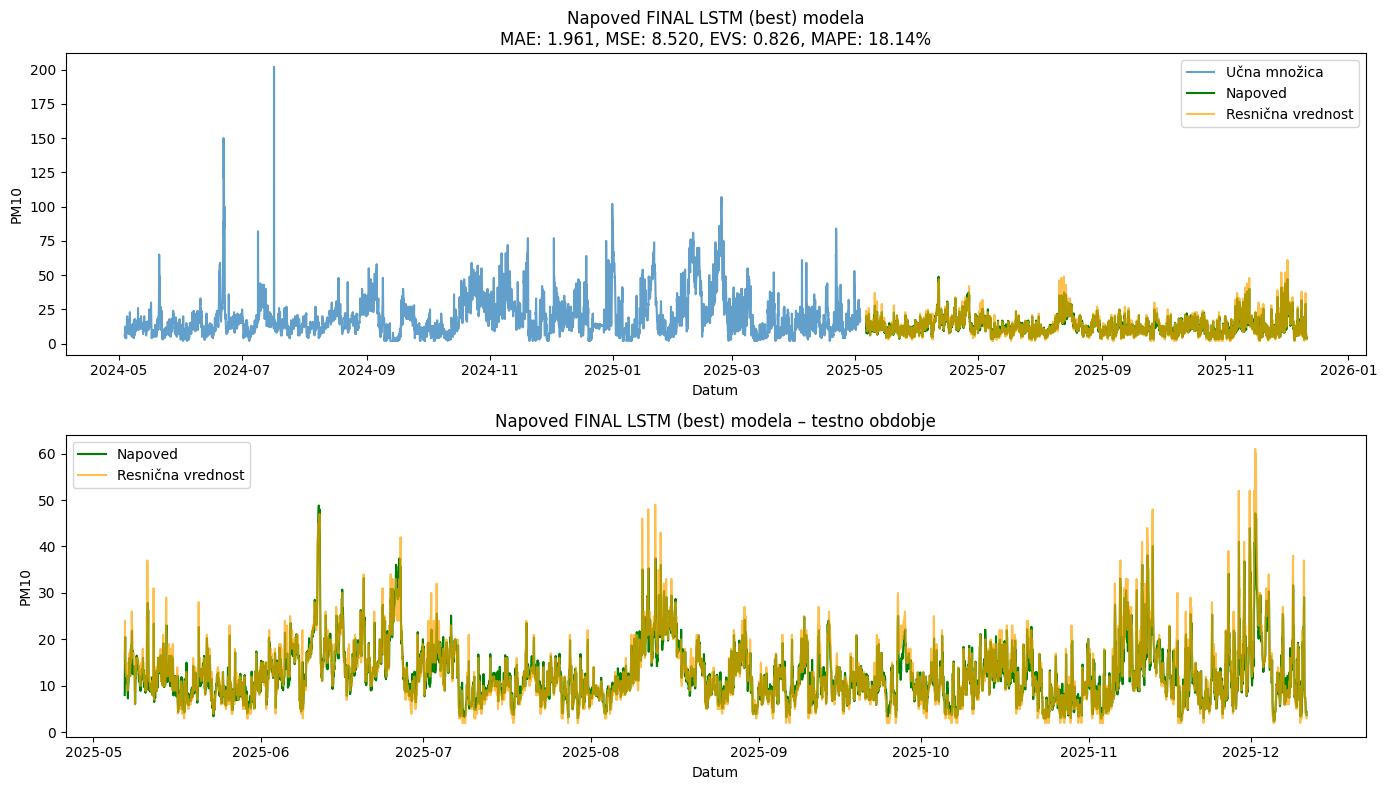

In [60]:
#Grafa za the best model
def plot_final_two_graphs(model, model_name, train_df, test_df, X_test_seq, y_test_seq_log,
                          target_log_col="PM10_log", window_size=72):
    # Priprava true/pred v REAL skali (PM10)
    y_pred_log = model.predict(X_test_seq).reshape(-1)

    y_true_test = np.expm1(y_test_seq_log.reshape(-1))
    y_pred_test = np.expm1(y_pred_log)

    # datumi za test: ker okna dolžine window_size -> target začne šele pri indexu window_size
    test_dates = test_df["datetime"].iloc[window_size:].reset_index(drop=True)

    # varnost: poravnava dolžin (če bi kdaj prišlo do 1 razlike)
    n = min(len(test_dates), len(y_true_test), len(y_pred_test))
    test_dates = test_dates.iloc[:n]
    y_true_test = y_true_test[:n]
    y_pred_test = y_pred_test[:n]

    # Učna množica (celotna) v real skali 
    y_train_full = np.expm1(train_df[target_log_col].astype(float).values.reshape(-1))
    train_dates_full = train_df["datetime"].reset_index(drop=True)

    # Metrike na testu (v real skali)
    mae = mean_absolute_error(y_true_test, y_pred_test)
    mse = mean_squared_error(y_true_test, y_pred_test)
    evs = explained_variance_score(y_true_test, y_pred_test)

    mask = y_true_test != 0
    mape = np.mean(np.abs((y_true_test[mask] - y_pred_test[mask]) / y_true_test[mask])) * 100

    print(f"{model_name} - MAE: {mae:.3f}, MSE: {mse:.3f}, EVS: {evs:.3f}, MAPE: {mape:.2f}%")

    # risanje grafov
    plt.figure(figsize=(14, 8))

    # GRAF 1: celoten pregled
    plt.subplot(2, 1, 1)
    plt.plot(train_dates_full, y_train_full, label="Učna množica", alpha=0.7)
    plt.plot(test_dates, y_pred_test, label="Napoved", color="green")
    plt.plot(test_dates, y_true_test, label="Resnična vrednost", color="orange", alpha=0.7)

    plt.xlabel("Datum")
    plt.ylabel("PM10")
    plt.title(
        f"Napoved {model_name} modela\n"
        f"MAE: {mae:.3f}, MSE: {mse:.3f}, EVS: {evs:.3f}, MAPE: {mape:.2f}%"
    )
    plt.legend()

    # GRAF 2: zoom na testno obdobje
    plt.subplot(2, 1, 2)
    plt.plot(test_dates, y_pred_test, label="Napoved", color="green")
    plt.plot(test_dates, y_true_test, label="Resnična vrednost", color="orange", alpha=0.7)

    plt.xlabel("Datum")
    plt.ylabel("PM10")
    plt.title(f"Napoved {model_name} modela – testno obdobje")
    plt.legend()

    plt.tight_layout()
    plt.show()


# KLIC (najboljši model)
plot_final_two_graphs(
    best_lstm_model,
    "FINAL LSTM (best)",
    train_df=train_df,
    test_df=test_df,
    X_test_seq=X_test_seq,
    y_test_seq_log=y_test_seq,
    target_log_col="PM10_log",
    window_size=WINDOW_SIZE
)

In [61]:
import joblib
import os

# mapa
os.makedirs("saved", exist_ok=True)

# shrani scaler
joblib.dump(scaler_X, "saved/scaler_X.pkl")

# shrani seznam feature-jev
joblib.dump(selected_features, "saved/selected_features.pkl")

# shrani model
best_lstm_model.save("saved/final_lstm_model.keras")

print("Shranjeno:")
print(" - saved/scaler_X.pkl")
print(" - saved/selected_features.pkl")
print(" - saved/final_lstm_model.keras")

Shranjeno:
 - saved/scaler_X.pkl
 - saved/selected_features.pkl
 - saved/final_lstm_model.keras
